Spatial Analysis




In [ ]:
#Connect Google Colab to Google Drive

from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


## SECTION 2.1 -INSTALL SPATIAL-ANALYSIS LIBRARIES


In [ ]:


#Install the packages needed to create geographic maps and
#calculate spatial-autocorrelation statistics.
#geopandas: manages geographic data
#shapely: converts and repairs geometry
#libpysal: creates spatial-neighbour weights
#esda: calculates Moran's I and Getis-Ord statistics
#mapclassify: groups map values into meaningful categories


!pip install geopandas libpysal esda mapclassify openpyxl -q

print("Spatial-analysis libraries installed successfully.")

Spatial-analysis libraries installed successfully.


## SECTION 2.2 -IMPORT SPATIAL-ANALYSIS LIBRARIES


In [ ]:



#Import the packages required for geometry conversion, mapping,
#spatial weights, Moran's I and hotspot analysis.


import geopandas as gpd
import mapclassify

from shapely import wkt
from shapely.geometry import Polygon, MultiPolygon
from shapely.validation import make_valid

from libpysal.weights import Queen, KNN
from esda.moran import Moran, Moran_Local
from esda.getisord import G_Local

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import os
import warnings

warnings.filterwarnings("ignore")

print("Spatial-analysis libraries imported successfully.")

Spatial-analysis libraries imported successfully.


## SECTION 2.3 -LOAD FINAL LA DATA AND 2024 LA BOUNDARIES


In [ ]:



#Rebuild the spatial dataset from the authoritative 2024 GeoJSON

#Join condition required:
#GeoJSON["LAD24CD"] == Excel["district_administrative_code"]



from pathlib import Path

FINAL_MAIN_3 = Path(
    "/content/drive/MyDrive/MSC Dissertation/Final Main 3"
)

if not FINAL_MAIN_3.exists():
    raise FileNotFoundError(
        f"Final Main 3 folder was not found: {FINAL_MAIN_3}"
    )


def find_file_in_final_main_3(
    preferred_relative_paths,
    exact_filenames
):
    """
    Resolve a file inside Final Main 3.

    1.Try the expected dissertation folder locations first.
    2.If the file has been moved within Final Main 3, search
       recursively for the exact filename.
    """

    for relative_path in preferred_relative_paths:
        candidate = FINAL_MAIN_3 / relative_path
        if candidate.exists():
            return candidate

    matches = []
    for filename in exact_filenames:
        matches.extend(FINAL_MAIN_3.rglob(filename))

    #Remove duplicates while preserving order.
    unique_matches = list(dict.fromkeys(matches))

    if len(unique_matches) == 1:
        return unique_matches[0]

    if len(unique_matches) > 1:
        print("Multiple candidate files were found:")
        for match in unique_matches:
            print(" -", match)
        print("\nUsing the first match shown above.")
        return unique_matches[0]

    raise FileNotFoundError(
        "Could not locate any of these files inside Final Main 3: "
        + ", ".join(exact_filenames)
    )


FINAL_LA_PATH = find_file_in_final_main_3(
    preferred_relative_paths=[
        "LA/Final_LA_Data.xlsx",
        "LA/Final_LA_data.xlsx",
        "Prepared Data/Final_LA_Data.xlsx",
        "Final_LA_Data.xlsx",
        "Final_LA_data.xlsx",
    ],
    exact_filenames=[
        "Final_LA_Data.xlsx",
        "Final_LA_data.xlsx",
    ]
)

LA_GEOJSON_PATH = find_file_in_final_main_3(
    preferred_relative_paths=[
        "LA/LA_Boundary/2024_UK_LABoundary.geojson",
        "Spatial Data/2024_UK_LABoundary.geojson",
        "LA/2024_UK_LABoundary.geojson",
        "2024_UK_LABoundary.geojson",
    ],
    exact_filenames=[
        "2024_UK_LABoundary.geojson",
    ]
)

print("Final LA data:")
print(FINAL_LA_PATH)

print("\n2024 LA boundary GeoJSON:")
print(LA_GEOJSON_PATH)

la_analysis = pd.read_excel(
    FINAL_LA_PATH,
    dtype={"district_administrative_code": "string"}
)

la_boundaries = gpd.read_file(
    LA_GEOJSON_PATH
)

print(
    f"\nFinal LA dataset dimensions: "
    f"{la_analysis.shape[0]} rows x "
    f"{la_analysis.shape[1]} columns"
)

print(
    f"GeoJSON dimensions: "
    f"{la_boundaries.shape[0]} rows x "
    f"{la_boundaries.shape[1]} columns"
)

display(la_analysis.head())
display(la_boundaries.head())


Final LA data:
/content/drive/MyDrive/MSC Dissertation/Final Main 3/LA/Final_LA_data.xlsx

2024 LA boundary GeoJSON:
/content/drive/MyDrive/MSC Dissertation/Final Main 3/LA/LA_Boundary/2024_UK_LABoundary.geojson

Final LA dataset dimensions: 294 rows x 23 columns
GeoJSON dimensions: 361 rows x 10 columns


,LA Authority,LA to LEA Mapped,Urbanity,Total no of pupils,Total no of Schools,Average SEN Rate,Average EHC Rate,Average Total SEND Rate,Average IMD Score,Average Income Score Rate,...,Total Population,Total Dependent child Population (0-15),Total working age Population (18-66),No of \nspecial schools,geo-Political Zone,new_la_code,district_administrative_code,LAD24NM,LAD24CD,geometry
0,Adur,West Sussex,1,9099,21,0.173796,0.141539,0.315335,14.962000,0.183286,...,64725,11704,37632,2,South East,E10000032,E07000223,Adur,E07000223,"MULTIPOLYGON (((-0.279155 50.829507, -0.280235..."
1,Amber Valley,Derbyshire,1,18726,73,0.149091,0.100391,0.249483,18.712671,0.191886,...,126934,21150,77288,5,East Midlands,E10000007,E07000032,Amber Valley,E07000032,"POLYGON ((-1.495366 53.133965, -1.493616 53.13..."
2,Arun,West Sussex,1,18895,46,0.144209,0.110469,0.254678,19.328970,0.190020,...,166381,25398,94293,2,South East,E10000032,E07000224,Arun,E07000224,"MULTIPOLYGON (((-0.749958 50.756688, -0.750031..."
3,Ashfield,Nottinghamshire,1,19899,49,0.121130,0.095981,0.217111,25.817623,0.261688,...,127101,23467,78109,4,East Midlands,E10000024,E07000170,Ashfield,E07000170,"POLYGON ((-1.284152 53.168382, -1.281992 53.16..."
4,Ashford,Kent,2,23207,62,0.127334,0.162138,0.289471,19.869074,0.203667,...,135741,26712,81863,8,South East,E10000016,E07000105,Ashford,E07000105,"POLYGON ((0.955032 51.270246, 0.958151 51.2685..."


,FID,LAD24CD,LAD24NM,LAD24NMW,BNG_E,BNG_N,LONG,LAT,GlobalID,geometry
0,1,E06000001,Hartlepool,,447161,531473,-1.27017,54.67613,b2299bd8-2f81-47c8-a203-f221a8660406,"MULTIPOLYGON (((-1.23001 54.62512, -1.2299 54...."
1,2,E06000002,Middlesbrough,,451141,516887,-1.21100,54.54468,780afbcf-fa9e-4e4d-8170-1c4a5900e3fe,"MULTIPOLYGON (((-1.27712 54.54791, -1.2772 54...."
2,3,E06000003,Redcar and Cleveland,,464330,519596,-1.00657,54.56752,2a60d0ee-9a32-475e-9775-443544dfbe28,"MULTIPOLYGON (((-1.20098 54.57763, -1.20037 54..."
3,4,E06000004,Stockton-on-Tees,,444940,518179,-1.30665,54.55688,58779371-c8f8-4dbb-b961-aec926c042e4,"MULTIPOLYGON (((-1.27493 54.55187, -1.27546 54..."
4,5,E06000005,Darlington,,428029,515648,-1.56836,54.53534,aa757c05-0702-4b3c-be47-f07524ae3f38,"POLYGON ((-1.638 54.6172, -1.63767 54.6167, -1..."


## SECTION 2.4 -VALIDATE THE JOIN AND ANALYSIS COLUMNS


In [ ]:



#Confirm that:
#-district_administrative_code exists in Final_LA_Data.xlsx;
#-LAD24CD exists in the GeoJSON;
#-the SEND outcomes required by the spatial analysis are present.


REQUIRED_LA_COLUMNS = [
    "LA Authority",
    "district_administrative_code",
    "Average SEN Rate",
    "Average EHC Rate",
    "Average Total SEND Rate"
]

REQUIRED_BOUNDARY_COLUMNS = [
    "LAD24CD",
    "geometry"
]

missing_la_columns = [
    column
    for column in REQUIRED_LA_COLUMNS
    if column not in la_analysis.columns
]

missing_boundary_columns = [
    column
    for column in REQUIRED_BOUNDARY_COLUMNS
    if column not in la_boundaries.columns
]

if missing_la_columns:
    raise KeyError(
        "Final_LA_Data.xlsx is missing required columns: "
        f"{missing_la_columns}"
    )

if missing_boundary_columns:
    raise KeyError(
        "The GeoJSON is missing required columns: "
        f"{missing_boundary_columns}"
    )

print("Required LA and GeoJSON columns are present.")
print(
    "Join rule: LAD24CD (GeoJSON) = "
    "district_administrative_code (Excel)"
)


Required LA and GeoJSON columns are present.
Join rule: LAD24CD (GeoJSON) = district_administrative_code (Excel)


## SECTION 2.5 -STANDARDISE GEOGRAPHIC CODES BEFORE JOINING


In [ ]:



#Geographic codes are identifiers, not numbers.Converting both
#keys to stripped strings prevents false non-matches caused by
#whitespace or Excel type inference.


la_analysis = la_analysis.copy()
la_boundaries = la_boundaries.copy()

la_analysis["district_administrative_code"] = (
    la_analysis["district_administrative_code"]
    .astype("string")
    .str.strip()
)

la_boundaries["LAD24CD"] = (
    la_boundaries["LAD24CD"]
    .astype("string")
    .str.strip()
)

blank_la_codes = (
    la_analysis["district_administrative_code"]
    .isna()
    | la_analysis["district_administrative_code"].eq("")
).sum()

blank_boundary_codes = (
    la_boundaries["LAD24CD"]
    .isna()
    | la_boundaries["LAD24CD"].eq("")
).sum()

print("Blank Excel district codes:", blank_la_codes)
print("Blank GeoJSON LAD24CD codes:", blank_boundary_codes)

duplicate_boundary_codes = (
    la_boundaries["LAD24CD"]
    .dropna()
    .duplicated()
    .sum()
)

print(
    "Duplicate LAD24CD rows in GeoJSON:",
    duplicate_boundary_codes
)

if duplicate_boundary_codes > 0:
    display(
        la_boundaries[
            la_boundaries["LAD24CD"].duplicated(
                keep=False
            )
        ].sort_values("LAD24CD")
    )


Blank Excel district codes: 0
Blank GeoJSON LAD24CD codes: 0
Duplicate LAD24CD rows in GeoJSON: 0


## SECTION 2.6 -JOIN FINAL LA DATA TO THE GEOJSON BOUNDARIES


In [ ]:



#Attach a fresh polygon geometry to every LA record using:
#
#GeoJSON LAD24CD = Final_LA_Data.xlsx district_administrative_code



excel_columns_to_remove = [
    column
    for column in [
        "geometry",
        "LAD24CD",
        "LAD24NM"
    ]
    if column in la_analysis.columns
]

la_attributes = la_analysis.drop(
    columns=excel_columns_to_remove,
    errors="ignore"
).copy()

boundary_columns = [
    "LAD24CD",
    "geometry"
]

if "LAD24NM" in la_boundaries.columns:
    boundary_columns.insert(1, "LAD24NM")

boundary_lookup = (
    la_boundaries[boundary_columns]
    .drop_duplicates(
        subset="LAD24CD",
        keep="first"
    )
    .copy()
)

la_joined = la_attributes.merge(
    boundary_lookup,
    how="left",
    left_on="district_administrative_code",
    right_on="LAD24CD",
    validate="many_to_one",
    indicator="_geometry_join"
)

la_gdf = gpd.GeoDataFrame(
    la_joined,
    geometry="geometry",
    crs=la_boundaries.crs
)

print("Fresh GeoJSON geometry joined to Final LA data.")
print("GeoDataFrame CRS:", la_gdf.crs)
print("Rows after join:", len(la_gdf))

join_summary = (
    la_gdf["_geometry_join"]
    .value_counts(dropna=False)
    .rename_axis("Join result")
    .reset_index(name="Number of LA rows")
)

display(join_summary)


Fresh GeoJSON geometry joined to Final LA data.
GeoDataFrame CRS: EPSG:4326
Rows after join: 294


,Join result,Number of LA rows
0,both,294
1,left_only,0
2,right_only,0


## SECTION 2.7 -AUDIT GEOMETRY MATCHES


In [ ]:

unmatched_geometry = (
    la_gdf[
        la_gdf["_geometry_join"] != "both"
    ][
        [
            "LA Authority",
            "district_administrative_code"
        ]
    ]
    .copy()
)

matched_count = (
    la_gdf["_geometry_join"]
    .eq("both")
    .sum()
)

unmatched_count = len(unmatched_geometry)

print("Successfully matched LA rows:", matched_count)
print("Unmatched LA rows:", unmatched_count)

if unmatched_count == 0:
    print(
        "SUCCESS: every LA row received geometry from the GeoJSON."
    )
else:
    print(
        "\nWARNING: the following LA rows did not match a "
        "GeoJSON LAD24CD code:"
    )
    display(unmatched_geometry)


excel_codes = set(
    la_analysis["district_administrative_code"]
    .dropna()
)

geojson_codes = set(
    la_boundaries["LAD24CD"]
    .dropna()
)

codes_missing_from_geojson = sorted(
    excel_codes -geojson_codes
)

print(
    "\nUnique Excel district codes absent from GeoJSON:",
    len(codes_missing_from_geojson)
)

if codes_missing_from_geojson:
    print(codes_missing_from_geojson)


Successfully matched LA rows: 294
Unmatched LA rows: 0
SUCCESS: every LA row received geometry from the GeoJSON.

Unique Excel district codes absent from GeoJSON: 0


## SECTION 2.8 -VALIDATE AND REPAIR JOINED GEOMETRIES


In [ ]:



#Check the freshly joined GeoJSON polygons and repair invalid
#geometry where GeoPandas/Shapely can do so safely.


la_gdf_with_geometry = (
    la_gdf[
        la_gdf.geometry.notna()
        & ~la_gdf.geometry.is_empty
    ]
    .copy()
)

invalid_before_repair = (
    ~la_gdf_with_geometry.geometry.is_valid
).sum()

print(
    "Invalid geometries before repair:",
    invalid_before_repair
)

la_gdf_with_geometry["geometry"] = (
    la_gdf_with_geometry["geometry"]
    .apply(
        lambda geometry:
        make_valid(geometry)
        if geometry is not None
        and not geometry.is_valid
        else geometry
    )
)

invalid_after_repair = (
    ~la_gdf_with_geometry.geometry.is_valid
).sum()

print(
    "Invalid geometries after repair:",
    invalid_after_repair
)

geometry_type_summary = (
    la_gdf_with_geometry["geometry"]
    .geom_type
    .value_counts(dropna=False)
    .rename_axis("Geometry Type")
    .reset_index(name="Number of LAs")
)

display(geometry_type_summary)


Invalid geometries before repair: 0
Invalid geometries after repair: 0


,Geometry Type,Number of LAs
0,Polygon,211
1,MultiPolygon,83


## SECTION 2.10 -REPROJECT TO THE BRITISH NATIONAL GRID


In [ ]:



#Reproject the newly merged GeoDataFrame to EPSG:27700 for
#neighbour construction and distance-aware spatial operations.


if la_gdf.crs is None:
    raise ValueError(
        "The GeoJSON has no CRS information."
        "A valid source CRS is required before reprojection."
    )

la_gdf_bng = la_gdf.to_crs(
    epsg=27700
)

print(
    "Source GeoJSON CRS:",
    la_gdf.crs
)

print(
    "Projected coordinate reference system:",
    la_gdf_bng.crs
)

print(
    "Number of LA geometries used downstream:",
    len(la_gdf_bng)
)


Source GeoJSON CRS: EPSG:4326
Projected coordinate reference system: EPSG:27700
Number of LA geometries used downstream: 294


## SECTION 2.11 -CHECK DUPLICATE GEOGRAPHIC IDENTIFIERS


In [ ]:



#Confirm that each Local Authority boundary code occurs only once.
#Duplicate codes could distort spatial weights and maps.


duplicate_boundary_codes = (
    la_gdf_bng[
        la_gdf_bng.duplicated(
            subset="LAD24CD",
            keep=False
        )
    ]
    .sort_values("LAD24CD")
)

print(
    "Number of duplicated LAD24CD codes:",
    duplicate_boundary_codes["LAD24CD"].nunique()
)

if len(duplicate_boundary_codes) > 0:

    duplicate_display_columns = [
        "LA Authority",
        "district_administrative_code",
        "LAD24CD"
    ]

    if "LAD24NM" in duplicate_boundary_codes.columns:
        duplicate_display_columns.append("LAD24NM")

    display(
        duplicate_boundary_codes[
            duplicate_display_columns
        ]
    )
else:
    print("No duplicate LAD24CD codes were found.")


Number of duplicated LAD24CD codes: 0
No duplicate LAD24CD codes were found.


## SECTION 2.12 -CREATE SEND PERCENTAGE FIELDS FOR MAPS


In [ ]:



#Convert the SEND outcome proportions into percentages.

#The original proportion fields remain unchanged for spatial
#statistics and regression analysis.


SPATIAL_RATE_TO_PERCENTAGE = {
    "Average SEN Rate": "SEN Support Percentage",
    "Average EHC Rate": "EHC Percentage",
    "Average Total SEND Rate": "Total SEND Percentage"
}

for rate_column, percentage_column in (
    SPATIAL_RATE_TO_PERCENTAGE.items()
):

    la_gdf_bng[percentage_column] = (
        la_gdf_bng[rate_column] * 100
    )

print("Percentage fields created for mapping.")

Percentage fields created for mapping.


## SECTION 2.13 -PLOT THE LOCAL AUTHORITY BOUNDARIES


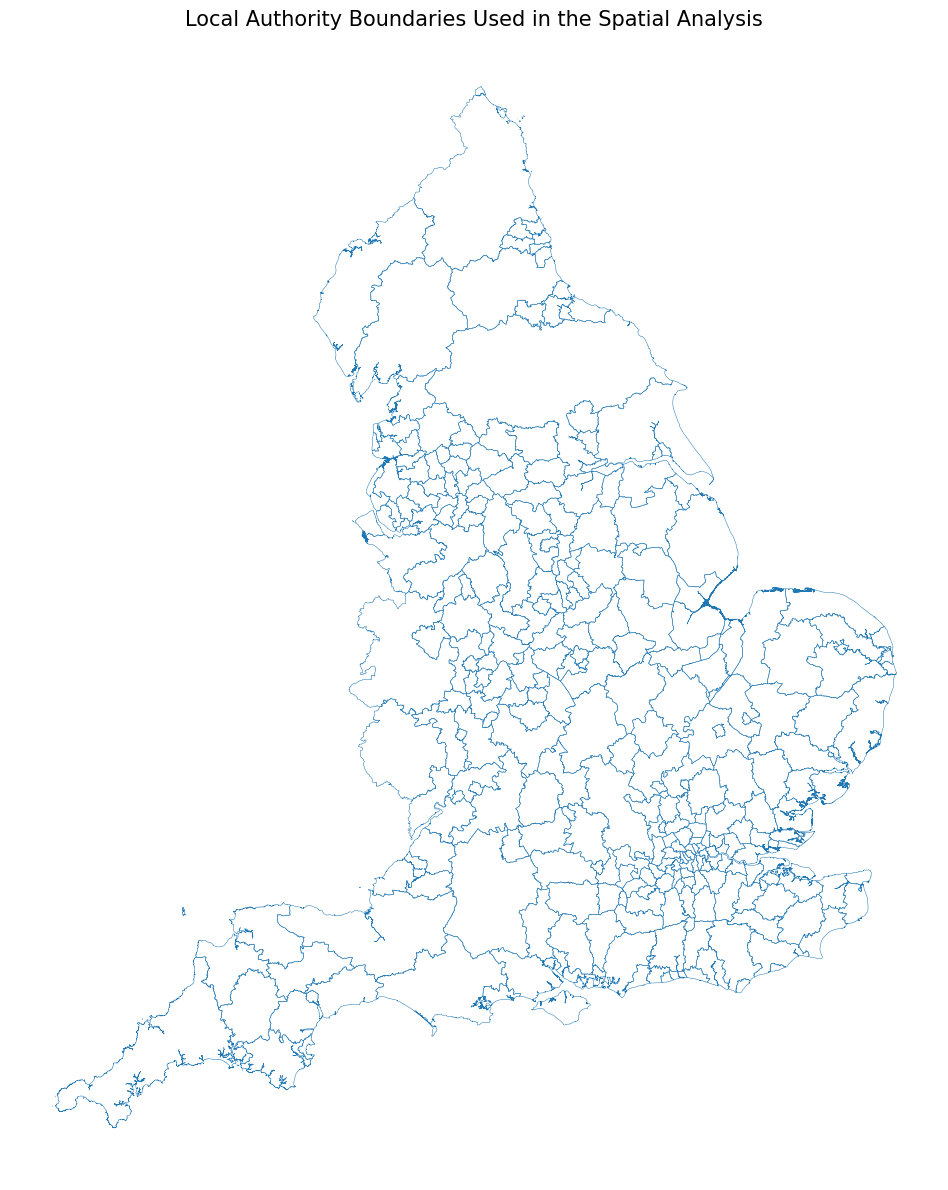

In [ ]:



#Visually confirm that the Local Authority geometries form a
#recognisable map of England before adding SEND values.




fig, ax = plt.subplots(
    figsize=(10, 12)
)

la_gdf_bng.boundary.plot(
    ax=ax,
    linewidth=0.35
)

ax.set_title(
    "Local Authority Boundaries Used in the Spatial Analysis",
    fontsize=15
)

ax.set_axis_off()

plt.tight_layout()
plt.show()

## SECTION 2.14 -DEFINE THE CHOROPLETH-MAP FUNCTION


In [ ]:



#Create consistent maps for SEN Support, EHC plans and Total SEND.
#
#Quantile classification places approximately equal numbers of
#Local Authorities in each of five categories.
#This makes relative geographic differences easier to see.


def create_choropleth_map(
    geodataframe,
    column,
    title,
    legend_title,
    output_path=None,
    number_of_classes=5
):
    """
    Create a quantile-classified Local Authority choropleth map.
    """

    fig, ax = plt.subplots(
        figsize=(10, 12)
    )

    geodataframe.plot(
        column=column,
        scheme="Quantiles",
        k=number_of_classes,
        legend=True,
        linewidth=0.25,
        edgecolor="white",
        ax=ax,
        missing_kwds={
            "label": "Missing",
            "hatch": "///"
        },
        legend_kwds={
            "title": legend_title,
            "loc": "lower left",
            "fontsize": 8,
            "title_fontsize": 9
        }
    )

    ax.set_title(
        title,
        fontsize=15,
        pad=12
    )

    ax.set_axis_off()

    plt.tight_layout()

    if output_path is not None:

        plt.savefig(
            output_path,
            dpi=300,
            bbox_inches="tight"
        )

    plt.show()

## SECTION 2.15 -CREATE THE SPATIAL-OUTPUT FOLDER


In [ ]:



#Store maps, tables and geographic files generated by the spatial analysis


SPATIAL_OUTPUT_FOLDER = (
    "/content/drive/MyDrive/MSC Dissertation/"
    "Final Main 3/Analysis Outputs/Spatial Analysis"
)

os.makedirs(
    SPATIAL_OUTPUT_FOLDER,
    exist_ok=True
)

print("Spatial-output folder:")
print(SPATIAL_OUTPUT_FOLDER)


Spatial-output folder:
/content/drive/MyDrive/MSC Dissertation/Final Main 3/Analysis Outputs/Spatial Analysis


## SECTION 2.16 -CHOROPLETH MAP OF SEN SUPPORT


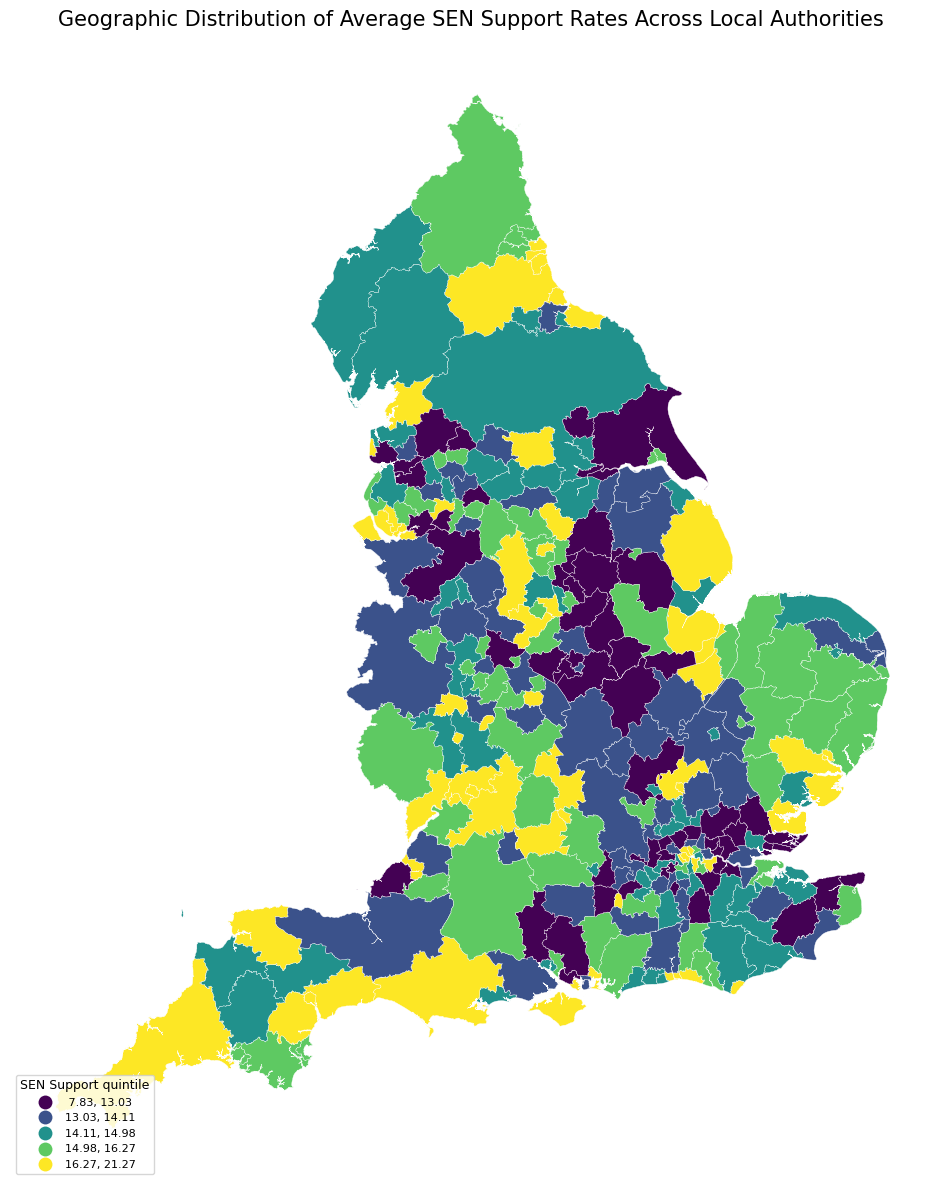

In [ ]:



#Show how average SEN Support rates vary geographically across
#Local Authorities in England.

#This map addresses the geographic-variation, before formal spatial testing.


SEN_MAP_PATH = os.path.join(
    SPATIAL_OUTPUT_FOLDER,
    "LA_SEN_Support_Choropleth.png"
)

create_choropleth_map(
    geodataframe=la_gdf_bng,
    column="SEN Support Percentage",
    title=(
        "Geographic Distribution of Average SEN Support Rates "
        "Across Local Authorities"
    ),
    legend_title="SEN Support quintile",
    output_path=SEN_MAP_PATH
)

## SECTION 2.17 -CHOROPLETH MAP OF EHC PLAN RATES


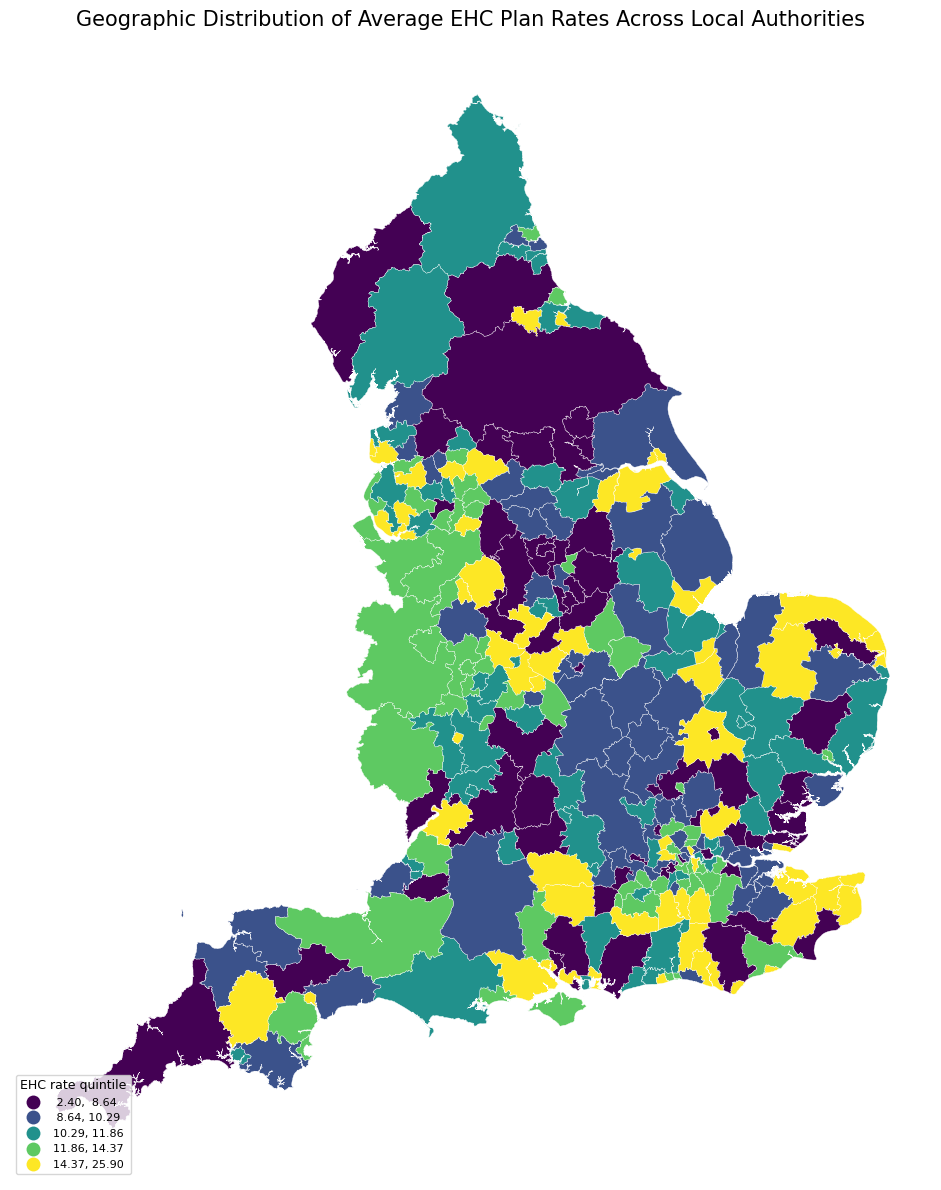

In [ ]:



#Show the geographic distribution of EHC plan prevalence.

#Differences in EHC rates are particularly relevant because EHC
#plans represent more formal and legally specified support.


EHC_MAP_PATH = os.path.join(
    SPATIAL_OUTPUT_FOLDER,
    "LA_EHC_Rate_Choropleth.png"
)

create_choropleth_map(
    geodataframe=la_gdf_bng,
    column="EHC Percentage",
    title=(
        "Geographic Distribution of Average EHC Plan Rates "
        "Across Local Authorities"
    ),
    legend_title="EHC rate quintile",
    output_path=EHC_MAP_PATH
)

## SECTION 2.18 -CHOROPLETH MAP OF TOTAL SEND RATES


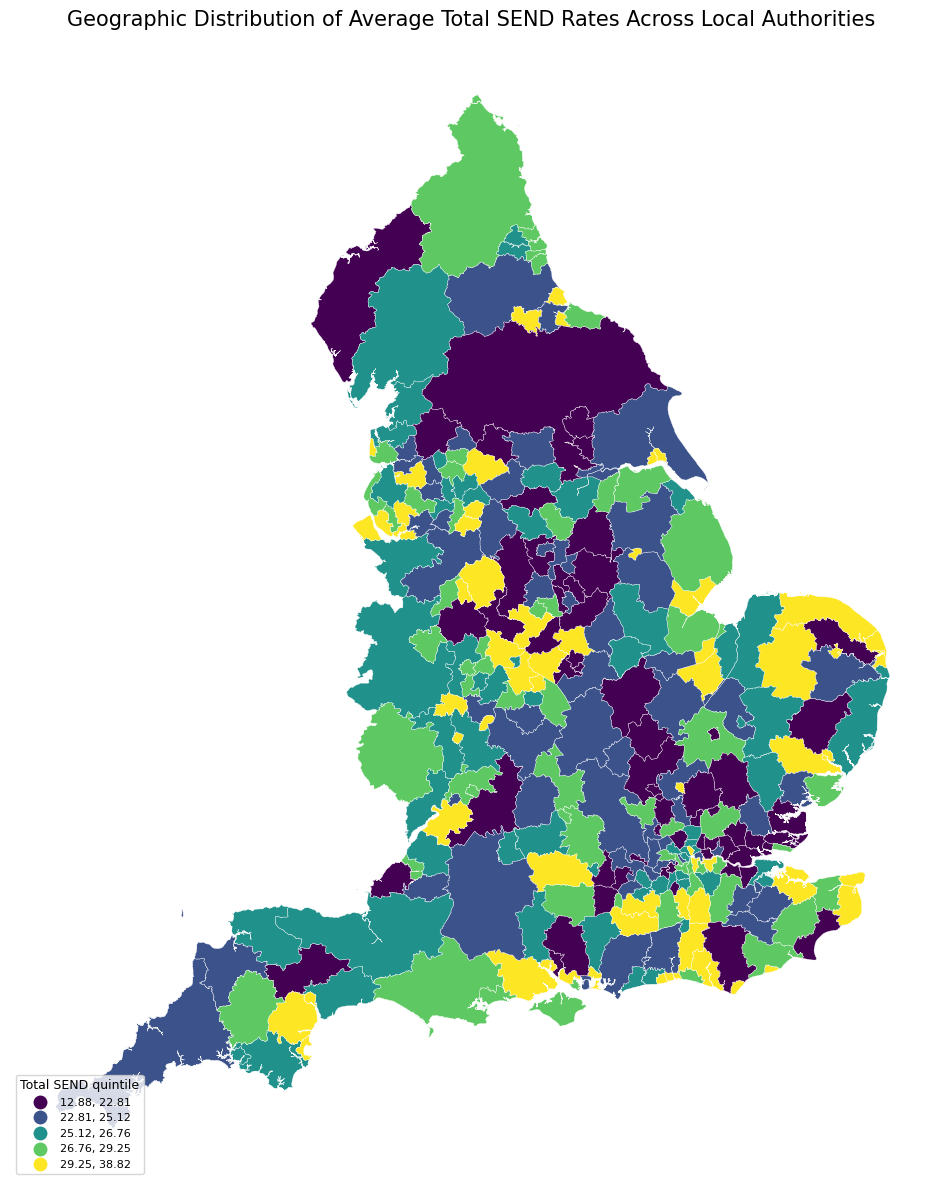

In [ ]:



#Show overall SEND prevalence by combining SEN Support and EHC
#plan rates.

#This provides a summary view of identified SEND provision across
#England.


TOTAL_SEND_MAP_PATH = os.path.join(
    SPATIAL_OUTPUT_FOLDER,
    "LA_Total_SEND_Choropleth.png"
)

create_choropleth_map(
    geodataframe=la_gdf_bng,
    column="Total SEND Percentage",
    title=(
        "Geographic Distribution of Average Total SEND Rates "
        "Across Local Authorities"
    ),
    legend_title="Total SEND quintile",
    output_path=TOTAL_SEND_MAP_PATH
)

## SECTION 2.19 -CREATE QUEEN-CONTIGUITY SPATIAL WEIGHTS


In [ ]:



#Define Local Authorities as neighbours when their boundaries
#share either:
#-an edge; or
#-a corner.

#Queen contiguity is commonly used for administrative-area data
#because it captures a broad definition of geographic adjacency.


queen_weights = Queen.from_dataframe(
    la_gdf_bng,
    ids=la_gdf_bng["LAD24CD"].tolist(),
    use_index=False
)

queen_weights.transform = "R"

print("Queen spatial weights created.")
print("Number of authorities:", queen_weights.n)
print(
    "Average number of neighbours:",
    round(queen_weights.mean_neighbors, 2)
)
print(
    "Minimum number of neighbours:",
    queen_weights.min_neighbors
)
print(
    "Maximum number of neighbours:",
    queen_weights.max_neighbors
)
print(
    "Number of disconnected authorities:",
    len(queen_weights.islands)
)

('WARNING: ', 'E06000046', ' is an island (no neighbors)')
Queen spatial weights created.
Number of authorities: 294
Average number of neighbours: 5.04
Minimum number of neighbours: 0
Maximum number of neighbours: 15
Number of disconnected authorities: 1


## SECTION 2.20 -INSPECT DISCONNECTED AUTHORITIES


In [ ]:

#Identify authorities with no Queen-contiguity neighbours.


queen_island_codes = queen_weights.islands

if len(queen_island_codes) == 0:

    print(
        "No disconnected authorities were found "
        "under Queen contiguity."
    )

else:

    print(
        "Disconnected boundary codes:",
        queen_island_codes
    )

    queen_island_authorities = (
        la_gdf_bng[
            la_gdf_bng["LAD24CD"].isin(
                queen_island_codes
            )
        ]
        .copy()
    )

    island_display_columns = [
        "LA Authority",
        "district_administrative_code",
        "LAD24CD"
    ]

    if "LAD24NM" in queen_island_authorities.columns:
        island_display_columns.append("LAD24NM")

    display(
        queen_island_authorities[
            island_display_columns
        ]
    )


Disconnected boundary codes: ['E06000046']


,LA Authority,district_administrative_code,LAD24CD,LAD24NM
124,Isle of Wight,E06000046,E06000046,Isle of Wight


## SECTION 2.21 -SELECT THE FINAL SPATIAL WEIGHTS MATRIX


In [ ]:



#Use Queen contiguity as the preferred spatial structure.

#If Queen contiguity produces disconnected authorities, create a
#four-nearest-neighbour matrix using authority centroids.

#K-nearest neighbours ensures every authority has neighbours and
#avoids dropping island or separated authorities from the study.


if len(queen_weights.islands) == 0:

    spatial_weights = queen_weights
    spatial_weights_method = "Queen contiguity"

else:

    spatial_weights = KNN.from_dataframe(
        la_gdf_bng,
        k=4,
        ids=la_gdf_bng["LAD24CD"].tolist(),
        use_index=False
    )

    spatial_weights.transform = "R"
    spatial_weights_method = "Four-nearest neighbours"

print(
    "Final spatial-weights method:",
    spatial_weights_method
)

print(
    "Number of observations:",
    spatial_weights.n
)

print(
    "Average number of neighbours:",
    round(spatial_weights.mean_neighbors, 2)
)

print(
    "Number of disconnected authorities:",
    len(spatial_weights.islands)
)

Final spatial-weights method: Four-nearest neighbours
Number of observations: 294
Average number of neighbours: 4.0
Number of disconnected authorities: 0


## SECTION 2.22 -CREATE THE NEIGHBOURHOOD-SUMMARY TABLE


In [ ]:



#Record the number of spatial neighbours assigned to each Local
#Authority.

#This improves transparency about the spatial structure that will be used later


neighbour_count_lookup = {
    authority_code: len(neighbours)
    for authority_code, neighbours
    in spatial_weights.neighbors.items()
}

la_gdf_bng["Number of Spatial Neighbours"] = (
    la_gdf_bng["LAD24CD"]
    .map(neighbour_count_lookup)
)

neighbour_summary = (
    la_gdf_bng[
        [
            "LA Authority",
            "LAD24CD",
            "Number of Spatial Neighbours"
        ]
    ]
    .sort_values(
        "Number of Spatial Neighbours"
    )
)

display(neighbour_summary.head(15))

,LA Authority,LAD24CD,Number of Spatial Neighbours
287,Wolverhampton,E08000031,4
286,Wokingham,E06000041,4
285,Woking,E07000217,4
284,Wirral,E08000015,4
283,Windsor and Maidenhead,E06000040,4
282,Winchester,E07000094,4
281,Wiltshire,E06000054,4
280,Wigan,E08000010,4
279,Westmorland and Furness,E06000064,4
278,Westminster,E09000033,4


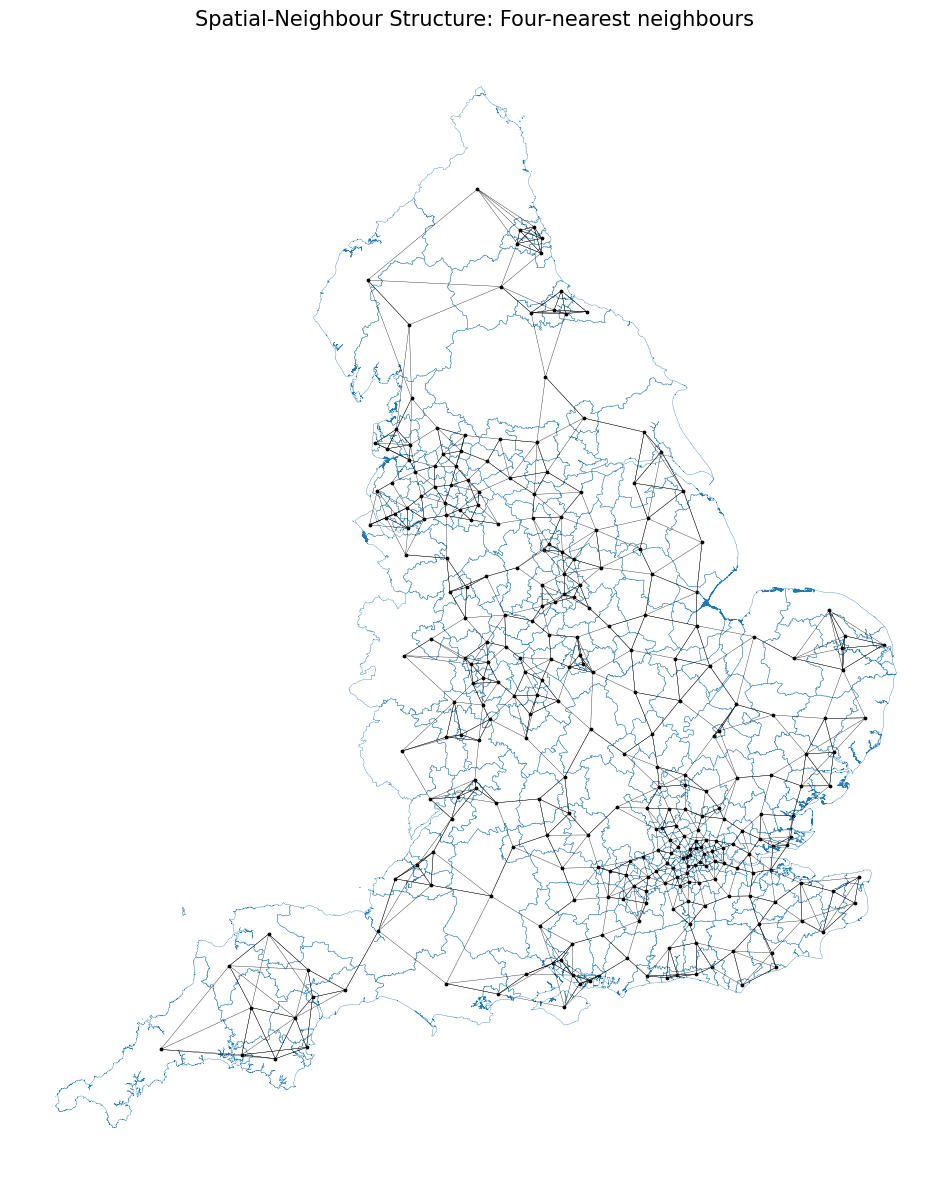

In [ ]:
import matplotlib.pyplot as plt

#Display the neighbourhood links used by the spatial statistics.

#The boundary layer shows the Local Authorities, while connecting
#lines indicate the neighbour relationships.


fig, ax = plt.subplots(
    figsize=(10, 12)
)

la_gdf_bng.boundary.plot(
    ax=ax,
    linewidth=0.25
)

spatial_weights.plot(
    la_gdf_bng,
    ax=ax,
    indexed_on="LAD24CD",
    node_kws={
        "s": 3
    },
    edge_kws={
        "linewidth": 0.25
    }
)

ax.set_title(
    f"Spatial-Neighbour Structure: {spatial_weights_method}",
    fontsize=15
)

ax.set_axis_off()

plt.tight_layout()
plt.show()

## SECTION 2.24 -DEFINE THE GLOBAL MORAN'S I FUNCTION


In [ ]:



#Test whether similar SEND rates occur near each other across
#England more often than expected under spatial randomness.
#
#Moran's I interpretation:
#Positive and significant = similar values cluster together
#Near zero = approximately random spatial pattern
#Negative and significant = neighbouring values tend to differ


def calculate_global_moran(
    geodataframe,
    outcome_column,
    weights,
    permutations=999
):
    """
    Calculate Global Moran's I for one outcome.
    """

    values = (
        geodataframe[outcome_column]
        .astype(float)
        .to_numpy()
    )

    moran_result = Moran(
        values,
        weights,
        permutations=permutations
    )

    result = {
        "Outcome": outcome_column,
        "Moran's I": moran_result.I,
        "Expected I": moran_result.EI,
        "Permutation p-value": moran_result.p_sim,
        "Z-score": moran_result.z_sim,
        "Permutations": permutations
    }

    return moran_result, result

## SECTION 2.25 -CALCULATE GLOBAL MORAN'S I


In [ ]:



#Test national spatial clustering separately for:
#1.SEN Support Rate
#2.EHC Rate
#3.Total SEND Rate


#Separate tests are needed because the three outcomes may have
#different geographic patterns.


SPATIAL_OUTCOMES = [
    "Average SEN Rate",
    "Average EHC Rate",
    "Average Total SEND Rate"
]

global_moran_objects = {}
global_moran_results = []

for outcome in SPATIAL_OUTCOMES:

    moran_object, moran_summary = (
        calculate_global_moran(
            geodataframe=la_gdf_bng,
            outcome_column=outcome,
            weights=spatial_weights,
            permutations=999
        )
    )

    global_moran_objects[outcome] = moran_object
    global_moran_results.append(
        moran_summary
    )

global_moran_table = pd.DataFrame(
    global_moran_results
)

display(
    global_moran_table.round(4)
)

,Outcome,Moran's I,Expected I,Permutation p-value,Z-score,Permutations
0,Average SEN Rate,0.2576,-0.0034,0.001,7.0362,999
1,Average EHC Rate,0.1065,-0.0034,0.004,2.8228,999
2,Average Total SEND Rate,0.2097,-0.0034,0.001,5.5071,999


## SECTION 2.26 -INTERPRET GLOBAL MORAN'S I RESULTS


In [ ]:



#Convert the numeric Moran results into concise descriptions.
#

#The interpretation is based on:
#-the sign of Moran's I;
#-the permutation p-value;
#-the 5% significance level.


def interpret_moran_result(
    moran_i,
    p_value,
    significance_level=0.05
):
    """
    Return a plain-language interpretation of Moran's I.
    """

    if p_value >= significance_level:
        return (
            "No statistically significant evidence "
            "of global spatial autocorrelation"
        )

    if moran_i > 0:
        return (
            "Statistically significant positive "
            "spatial clustering"
        )

    if moran_i < 0:
        return (
            "Statistically significant negative "
            "spatial autocorrelation"
        )

    return "Approximately spatially random"


global_moran_table["Interpretation"] = (
    global_moran_table.apply(
        lambda row:
        interpret_moran_result(
            row["Moran's I"],
            row["Permutation p-value"]
        ),
        axis=1
    )
)

display(
    global_moran_table[
        [
            "Outcome",
            "Moran's I",
            "Expected I",
            "Permutation p-value",
            "Z-score",
            "Interpretation"
        ]
    ].round(4)
)

,Outcome,Moran's I,Expected I,Permutation p-value,Z-score,Interpretation
0,Average SEN Rate,0.2576,-0.0034,0.001,7.0362,Statistically significant positive spatial clu...
1,Average EHC Rate,0.1065,-0.0034,0.004,2.8228,Statistically significant positive spatial clu...
2,Average Total SEND Rate,0.2097,-0.0034,0.001,5.5071,Statistically significant positive spatial clu...


## SECTION 2.28 -DEFINE THE LOCAL MORAN'S I FUNCTION


In [ ]:



#Identify the individual Local Authorities contributing to
#national spatial clustering.


#Local Moran categories:
#High-High = high authority surrounded by high authorities
#Low-Low = low authority surrounded by low authorities
#High-Low = high authority surrounded by low authorities
#Low-High = low authority surrounded by high authorities
#Not Significant = no significant local cluster


def calculate_local_moran(
    geodataframe,
    outcome_column,
    weights,
    permutations=999,
    significance_level=0.05
):
    """
    Calculate Local Moran's I and return a GeoDataFrame
    containing cluster classifications.
    """

    local_gdf = geodataframe.copy()

    values = (
        local_gdf[outcome_column]
        .astype(float)
        .to_numpy()
    )

    local_moran = Moran_Local(
        values,
        weights,
        permutations=permutations
    )

    quadrant_labels = {
        1: "High-High",
        2: "Low-High",
        3: "Low-Low",
        4: "High-Low"
    }

    local_gdf["Local Moran I"] = (
        local_moran.Is
    )

    local_gdf["Local Moran p-value"] = (
        local_moran.p_sim
    )

    local_gdf["LISA Quadrant"] = [
        quadrant_labels.get(
            quadrant,
            "Unclassified"
        )
        for quadrant in local_moran.q
    ]

    local_gdf["LISA Cluster"] = np.where(
        local_gdf["Local Moran p-value"]
        < significance_level,
        local_gdf["LISA Quadrant"],
        "Not Significant"
    )

    return local_gdf, local_moran

## SECTION 2.29 -CALCULATE LOCAL MORAN'S I


In [ ]:



#Identify High-High, Low-Low, High-Low and Low-High patterns for
#each of the three SEND outcomes.


local_moran_gdfs = {}
local_moran_objects = {}

for outcome in SPATIAL_OUTCOMES:

    lisa_gdf, lisa_object = (
        calculate_local_moran(
            geodataframe=la_gdf_bng,
            outcome_column=outcome,
            weights=spatial_weights,
            permutations=999,
            significance_level=0.05
        )
    )

    local_moran_gdfs[outcome] = lisa_gdf
    local_moran_objects[outcome] = lisa_object

    print(f"\nLocal Moran cluster counts: {outcome}")

    display(
        lisa_gdf["LISA Cluster"]
        .value_counts()
        .rename_axis("LISA Cluster")
        .reset_index(name="Number of LAs")
    )


Local Moran cluster counts: Average SEN Rate


,LISA Cluster,Number of LAs
0,Not Significant,218
1,Low-Low,33
2,High-High,31
3,High-Low,8
4,Low-High,4



Local Moran cluster counts: Average EHC Rate


,LISA Cluster,Number of LAs
0,Not Significant,255
1,Low-Low,18
2,Low-High,9
3,High-Low,7
4,High-High,5



Local Moran cluster counts: Average Total SEND Rate


,LISA Cluster,Number of LAs
0,Not Significant,234
1,Low-Low,23
2,High-High,17
3,Low-High,12
4,High-Low,8


## SECTION 2.30 -DEFINE THE LISA CLUSTER-MAP FUNCTION


In [ ]:



#Produce a consistent map of statistically significant Local
#Moran clusters and spatial outliers.


def create_lisa_cluster_map(
    lisa_geodataframe,
    title,
    output_path=None
):
    """
    Plot Local Moran cluster categories.
    """

    cluster_colours = {
        "High-High": "#d7191c",
        "Low-Low": "#2c7bb6",
        "High-Low": "#fdae61",
        "Low-High": "#abd9e9",
        "Not Significant": "#d9d9d9"
    }

    figure, axis = plt.subplots(
        figsize=(10, 12)
    )

    for cluster_name, colour in (
        cluster_colours.items()
    ):

        cluster_subset = lisa_geodataframe[
            lisa_geodataframe["LISA Cluster"]
            == cluster_name
        ]

        if len(cluster_subset) > 0:

            cluster_subset.plot(
                ax=axis,
                color=colour,
                edgecolor="white",
                linewidth=0.25
            )

    legend_patches = [
        mpatches.Patch(
            color=colour,
            label=cluster_name
        )
        for cluster_name, colour
        in cluster_colours.items()
    ]

    axis.legend(
        handles=legend_patches,
        title="Local Moran category",
        loc="lower left",
        fontsize=8,
        title_fontsize=9
    )

    axis.set_title(
        title,
        fontsize=15,
        pad=12
    )

    axis.set_axis_off()

    plt.tight_layout()

    if output_path is not None:

        plt.savefig(
            output_path,
            dpi=300,
            bbox_inches="tight"
        )

    plt.show()

## SECTION 2.31 -SEN SUPPORT LISA CLUSTER MAP


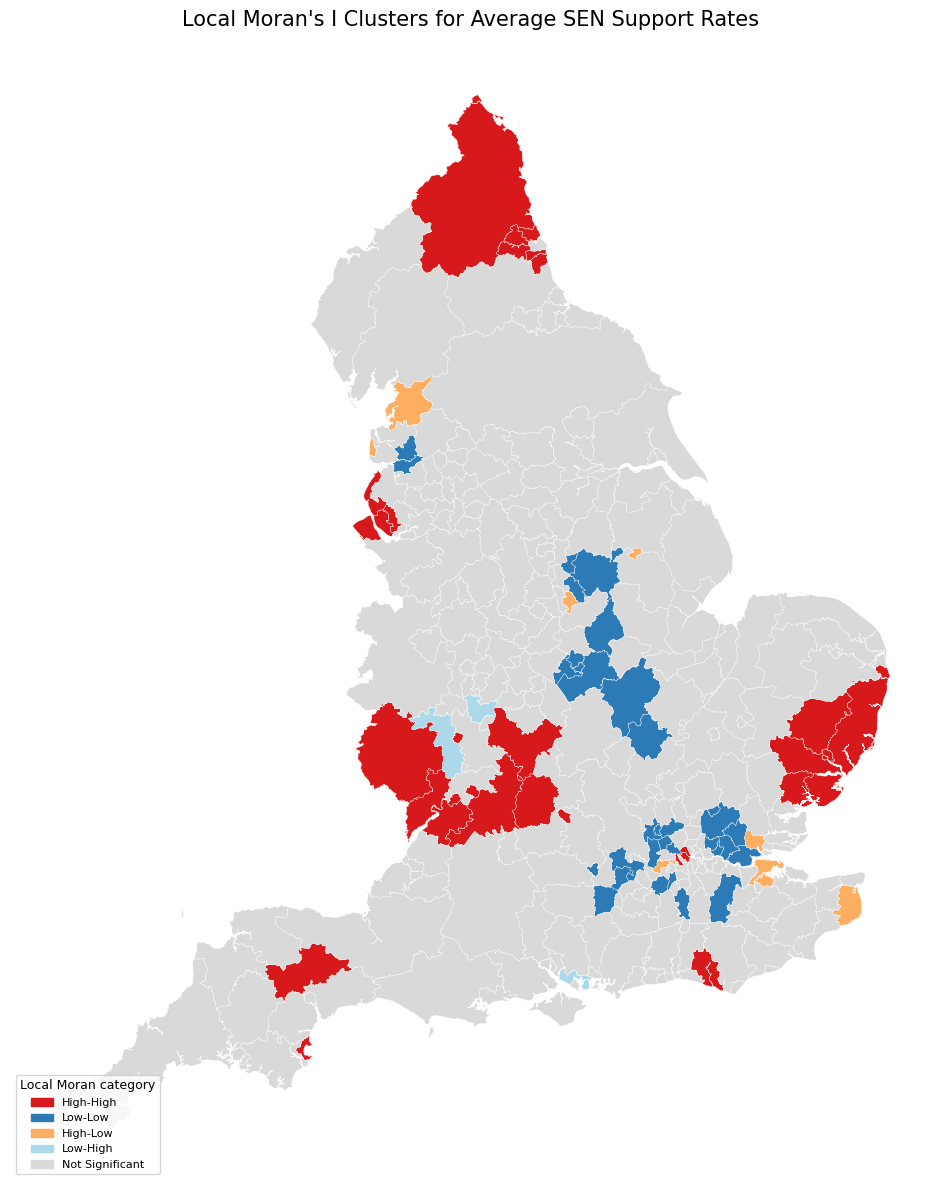

In [ ]:



#Identify statistically significant clusters and spatial outliers
#in SEN Support rates.


SEN_LISA_PATH = os.path.join(
    SPATIAL_OUTPUT_FOLDER,
    "LA_SEN_Support_LISA_Clusters.png"
)

create_lisa_cluster_map(
    lisa_geodataframe=local_moran_gdfs[
        "Average SEN Rate"
    ],
    title=(
        "Local Moran's I Clusters for "
        "Average SEN Support Rates"
    ),
    output_path=SEN_LISA_PATH
)

## SECTION 2.32 -EHC RATE LISA CLUSTER MAP


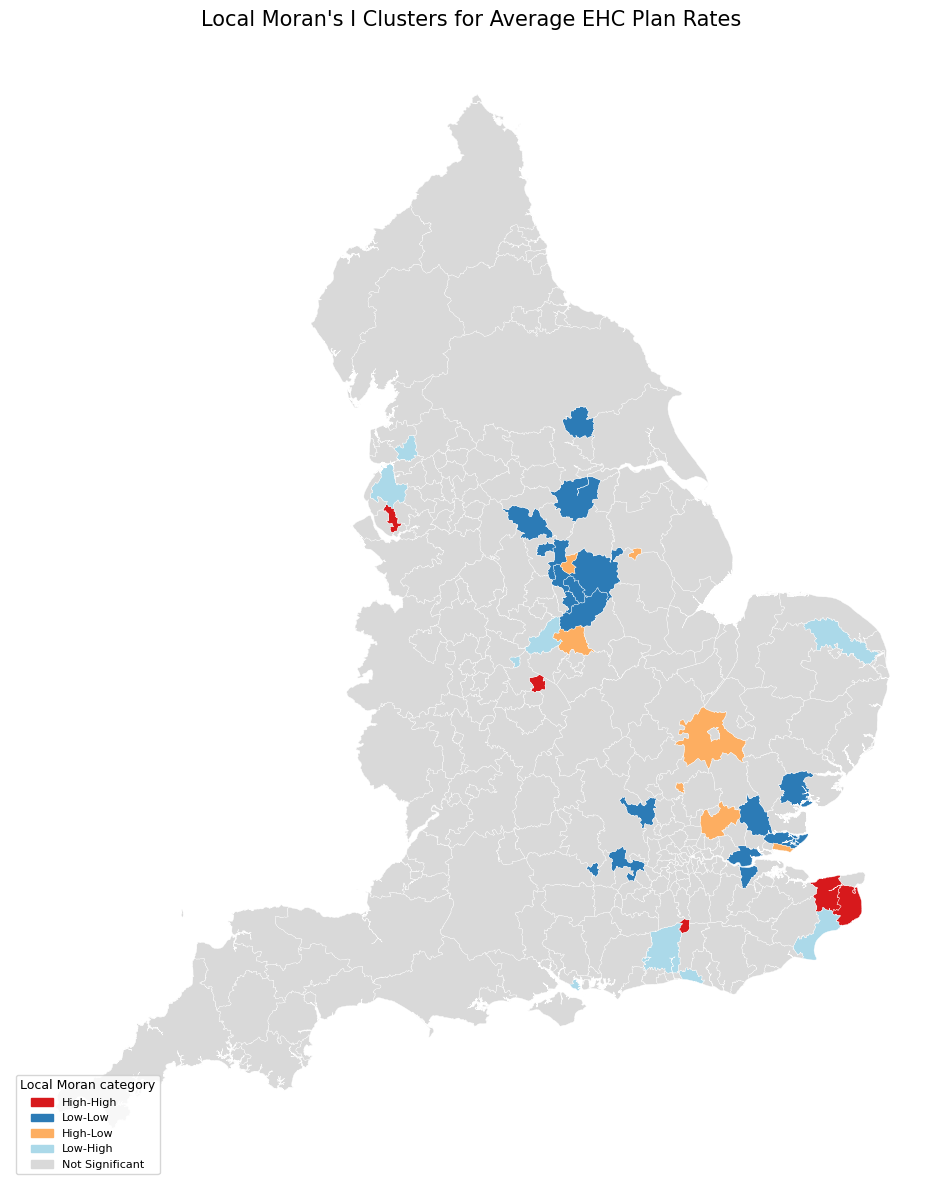

In [ ]:



#Identify significant local clusters and spatial outliers in EHCplan prevalence.


EHC_LISA_PATH = os.path.join(
    SPATIAL_OUTPUT_FOLDER,
    "LA_EHC_Rate_LISA_Clusters.png"
)

create_lisa_cluster_map(
    lisa_geodataframe=local_moran_gdfs[
        "Average EHC Rate"
    ],
    title=(
        "Local Moran's I Clusters for "
        "Average EHC Plan Rates"
    ),
    output_path=EHC_LISA_PATH
)

## SECTION 2.32 -EHC RATE LISA CLUSTER MAP


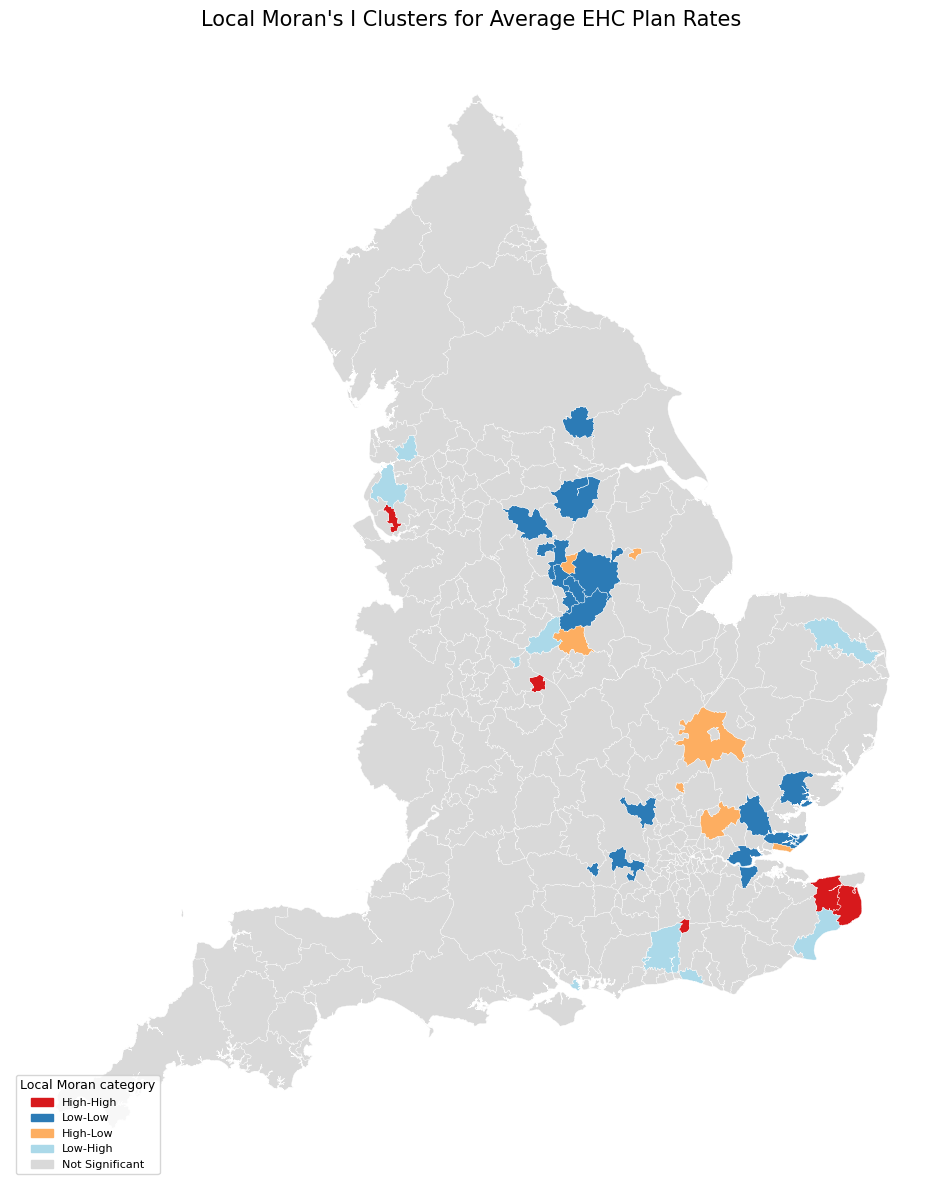

In [ ]:



#Identify significant local clusters and spatial outliers in EHCplan prevalence.


EHC_LISA_PATH = os.path.join(
    SPATIAL_OUTPUT_FOLDER,
    "LA_EHC_Rate_LISA_Clusters.png"
)

create_lisa_cluster_map(
    lisa_geodataframe=local_moran_gdfs[
        "Average EHC Rate"
    ],
    title=(
        "Local Moran's I Clusters for "
        "Average EHC Plan Rates"
    ),
    output_path=EHC_LISA_PATH
)

## SECTION 2.33 -TOTAL SEND LISA CLUSTER MAP


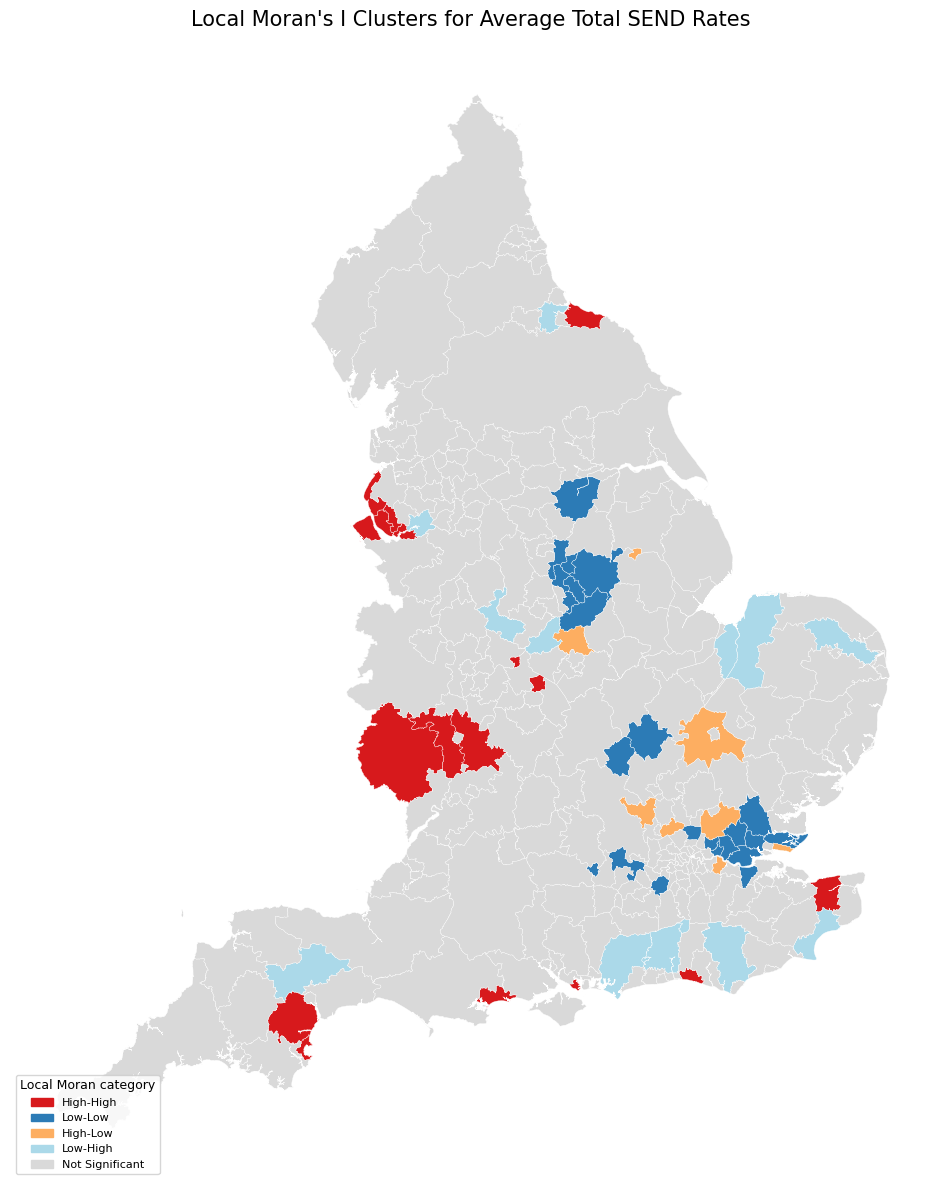

In [ ]:



#Identify significant clusters and spatial outliers in overall SEND prevalence.


TOTAL_SEND_LISA_PATH = os.path.join(
    SPATIAL_OUTPUT_FOLDER,
    "LA_Total_SEND_LISA_Clusters.png"
)

create_lisa_cluster_map(
    lisa_geodataframe=local_moran_gdfs[
        "Average Total SEND Rate"
    ],
    title=(
        "Local Moran's I Clusters for "
        "Average Total SEND Rates"
    ),
    output_path=TOTAL_SEND_LISA_PATH
)

## SECTION 2.34 -EXTRACT SIGNIFICANT LOCAL MORAN AUTHORITIES


In [ ]:



#Create dissertation-ready tables listing the authorities within
#each significant spatial cluster or outlier category.


significant_lisa_tables = {}

for outcome, lisa_gdf in (
    local_moran_gdfs.items()
):

    significant_table = (
        lisa_gdf[
            lisa_gdf["LISA Cluster"]
            != "Not Significant"
        ][
            [
                "LA Authority",
                "LAD24CD",
                outcome,
                "LISA Cluster",
                "Local Moran I",
                "Local Moran p-value"
            ]
        ]
        .copy()
    )

    significant_table[
        "Outcome Percentage"
    ] = (
        significant_table[outcome] * 100
    )

    significant_table = (
        significant_table
        .sort_values(
            [
                "LISA Cluster",
                "Outcome Percentage"
            ],
            ascending=[
                True,
                False
            ]
        )
    )

    significant_lisa_tables[outcome] = (
        significant_table
    )

    print("=" * 75)
    print(
        f"Significant Local Moran results: {outcome}"
    )

    display(
        significant_table[
            [
                "LA Authority",
                "Outcome Percentage",
                "LISA Cluster",
                "Local Moran I",
                "Local Moran p-value"
            ]
        ].round(4)
    )

Significant Local Moran results: Average SEN Rate


,LA Authority,Outcome Percentage,LISA Cluster,Local Moran I,Local Moran p-value
284,Wirral,19.2682,High-High,2.9003,0.009
92,Forest of Dean,18.3959,High-High,1.9073,0.025
123,Ipswich,18.1631,High-High,1.9923,0.023
5,Babergh,17.9629,High-High,1.9243,0.017
247,Tendring,17.8138,High-High,2.0340,0.006
...,...,...,...,...,...
187,Redbridge,11.7275,Low-Low,1.4282,0.021
157,Newark and Sherwood,11.5633,Low-Low,2.1485,0.003
220,South Ribble,11.4457,Low-Low,1.8867,0.010
28,Brentwood,10.9371,Low-Low,1.6878,0.032


Significant Local Moran results: Average EHC Rate


,LA Authority,Outcome Percentage,LISA Cluster,Local Moran I,Local Moran p-value
177,Nuneaton and Bedworth,16.8344,High-High,1.7077,0.027
70,Dover,15.7248,High-High,1.5946,0.008
43,Canterbury,14.4381,High-High,1.1997,0.005
60,Crawley,11.4747,High-High,0.0278,0.003
131,Knowsley,11.4495,High-High,0.0133,0.020
46,Charnwood,16.5354,High-Low,-1.2768,0.036
139,Lincoln,15.5110,High-Low,-1.0995,0.027
212,South Cambridgeshire,15.3824,High-Low,-1.2247,0.019
224,Southend-on-Sea,15.0827,High-Low,-1.0211,0.024
85,Epping Forest,14.9682,High-Low,-0.9419,0.026


Significant Local Moran results: Average Total SEND Rate


,LA Authority,Outcome Percentage,LISA Cluster,Local Moran I,Local Moran p-value
284,Wirral,33.2721,High-High,2.3443,0.004
140,Liverpool,33.1350,High-High,2.7003,0.002
103,Halton,32.9824,High-High,1.6009,0.024
177,Nuneaton and Bedworth,32.1883,High-High,1.3661,0.033
245,Teignbridge,31.3071,High-High,1.2276,0.027
254,Torbay,29.4019,High-High,0.7365,0.040
188,Redcar and Cleveland,29.2148,High-High,0.6867,0.037
131,Knowsley,29.1951,High-High,1.4044,0.001
205,Sefton,28.5541,High-High,0.6472,0.020
22,"Bournemouth, Christchurch and P",28.2809,High-High,0.5304,0.021


## SECTION 2.35 -IDENTIFY LOCAL SPATIAL CONTRASTS


In [ ]:



#Focus on High-Low and Low-High authorities.
#
#These spatial outliers are especially relevant to the postcode-
#lottery argument because they differ from nearby authorities.


spatial_outlier_tables = {}

for outcome, lisa_gdf in (
    local_moran_gdfs.items()
):

    spatial_outliers = (
        lisa_gdf[
            lisa_gdf["LISA Cluster"].isin(
                [
                    "High-Low",
                    "Low-High"
                ]
            )
        ][
            [
                "LA Authority",
                "LAD24CD",
                outcome,
                "LISA Cluster",
                "Local Moran I",
                "Local Moran p-value"
            ]
        ]
        .copy()
    )

    spatial_outliers[
        "Outcome Percentage"
    ] = (
        spatial_outliers[outcome] * 100
    )

    spatial_outlier_tables[outcome] = (
        spatial_outliers
    )

    print(
        f"\nSpatial outliers for {outcome}:"
    )

    display(
        spatial_outliers[
            [
                "LA Authority",
                "Outcome Percentage",
                "LISA Cluster",
                "Local Moran p-value"
            ]
        ].round(4)
    )


Spatial outliers for Average SEN Rate:


,LA Authority,Outcome Percentage,LISA Cluster,Local Moran p-value
9,Basildon,14.7675,High-Low,0.009
18,Blackpool,16.7191,High-Low,0.012
33,Bromsgrove,13.0602,Low-High,0.042
70,Dover,15.0552,High-Low,0.034
89,Fareham,11.5152,Low-High,0.047
120,Hounslow,14.8869,High-Low,0.020
133,Lancaster,16.8367,High-Low,0.016
139,Lincoln,16.1697,High-Low,0.012
144,Malvern Hills,14.4430,Low-High,0.039
147,Medway,16.1806,High-Low,0.039



Spatial outliers for Average EHC Rate:


,LA Authority,Outcome Percentage,LISA Cluster,Local Moran p-value
29,Brighton and Hove,9.6223,Low-High,0.004
31,Broadland,6.0868,Low-High,0.027
46,Charnwood,16.5354,High-Low,0.036
85,Epping Forest,14.9682,High-Low,0.026
91,Folkestone and Hythe,7.0628,Low-High,0.011
97,Gosport,6.3287,Low-High,0.034
119,Horsham,10.5952,Low-High,0.018
139,Lincoln,15.5110,High-Low,0.027
146,Mansfield,12.2852,High-Low,0.022
172,North West Leicestershire,6.5450,Low-High,0.006



Spatial outliers for Average Total SEND Rate:


,LA Authority,Outcome Percentage,LISA Cluster,Local Moran p-value
14,Bexley,27.0914,High-Low,0.034
31,Broadland,19.5922,Low-High,0.024
46,Charnwood,29.6367,High-Low,0.009
53,Chichester,22.8783,Low-High,0.039
60,Crawley,25.5438,Low-High,0.009
63,Dacorum,27.2055,High-Low,0.009
79,East Staffordshire,20.7290,Low-High,0.043
85,Epping Forest,26.7631,High-Low,0.003
91,Folkestone and Hythe,20.6478,Low-High,0.039
115,Hertsmere,28.2369,High-Low,0.011


## SECTION 2.36 -DEFINE THE GETIS-ORD GI* HOTSPOT FUNCTION


In [ ]:



#Identify areas located within statistically significant
#concentrations of high or low SEND rates.

#Hotspot = significant concentration of high values
#Coldspot = significant concentration of low values


def calculate_getis_ord_hotspots(
    geodataframe,
    outcome_column,
    weights,
    permutations=999,
    significance_level=0.05
):
    """
    Calculate local Getis-Ord statistics and classify hotspots.
    """

    hotspot_gdf = geodataframe.copy()

    values = (
        hotspot_gdf[outcome_column]
        .astype(float)
        .to_numpy()
    )

    getis_result = G_Local(
        values,
        weights,
        permutations=permutations,
        star=True
    )

    hotspot_gdf["Gi Z-score"] = (
        getis_result.Zs
    )

    hotspot_gdf["Gi p-value"] = (
        getis_result.p_sim
    )

    conditions = [
        (
            hotspot_gdf["Gi p-value"]
            < significance_level
        )
        & (
            hotspot_gdf["Gi Z-score"] > 0
        ),
        (
            hotspot_gdf["Gi p-value"]
            < significance_level
        )
        & (
            hotspot_gdf["Gi Z-score"] < 0
        )
    ]

    categories = [
        "Hotspot",
        "Coldspot"
    ]

    hotspot_gdf["Gi Category"] = np.select(
        conditions,
        categories,
        default="Not Significant"
    )

    return hotspot_gdf, getis_result

## SECTION 2.37 -CALCULATE GETIS-ORD GI* HOTSPOTS


In [ ]:



#Identify high-value and low-value concentrations for each SEND
#outcome as supporting evidence for the Local Moran results.


getis_ord_gdfs = {}
getis_ord_objects = {}

for outcome in SPATIAL_OUTCOMES:

    hotspot_gdf, getis_object = (
        calculate_getis_ord_hotspots(
            geodataframe=la_gdf_bng,
            outcome_column=outcome,
            weights=spatial_weights,
            permutations=999,
            significance_level=0.05
        )
    )

    getis_ord_gdfs[outcome] = hotspot_gdf
    getis_ord_objects[outcome] = getis_object

    print(f"\nGetis-Ord categories: {outcome}")

    display(
        hotspot_gdf["Gi Category"]
        .value_counts()
        .rename_axis("Gi* Category")
        .reset_index(name="Number of LAs")
    )


Getis-Ord categories: Average SEN Rate


,Gi* Category,Number of LAs
0,Not Significant,224
1,Hotspot,35
2,Coldspot,35



Getis-Ord categories: Average EHC Rate


,Gi* Category,Number of LAs
0,Not Significant,254
1,Coldspot,24
2,Hotspot,16



Getis-Ord categories: Average Total SEND Rate


,Gi* Category,Number of LAs
0,Not Significant,241
1,Coldspot,31
2,Hotspot,22


## SECTION 2.38 -DEFINE THE GETIS-ORD HOTSPOT-MAP FUNCTION


In [ ]:



#Display statistically significant high-value hotspots and low-value coldspots.


def create_hotspot_map(
    hotspot_geodataframe,
    title,
    output_path=None
):
    """
    Plot Getis-Ord hotspot categories.
    """

    category_colours = {
        "Hotspot": "#d7191c",
        "Coldspot": "#2c7bb6",
        "Not Significant": "#d9d9d9"
    }

    figure, axis = plt.subplots(
        figsize=(10, 12)
    )

    for category, colour in (
        category_colours.items()
    ):

        category_subset = hotspot_geodataframe[
            hotspot_geodataframe["Gi Category"]
            == category
        ]

        if len(category_subset) > 0:

            category_subset.plot(
                ax=axis,
                color=colour,
                edgecolor="white",
                linewidth=0.25
            )

    legend_patches = [
        mpatches.Patch(
            color=colour,
            label=category
        )
        for category, colour
        in category_colours.items()
    ]

    axis.legend(
        handles=legend_patches,
        title="Getis-Ord Gi* category",
        loc="lower left",
        fontsize=8,
        title_fontsize=9
    )

    axis.set_title(
        title,
        fontsize=15,
        pad=12
    )

    axis.set_axis_off()

    plt.tight_layout()

    if output_path is not None:

        plt.savefig(
            output_path,
            dpi=300,
            bbox_inches="tight"
        )

    plt.show()

## SECTION 2.39 -CREATE GETIS-ORD GI* HOTSPOT MAPS


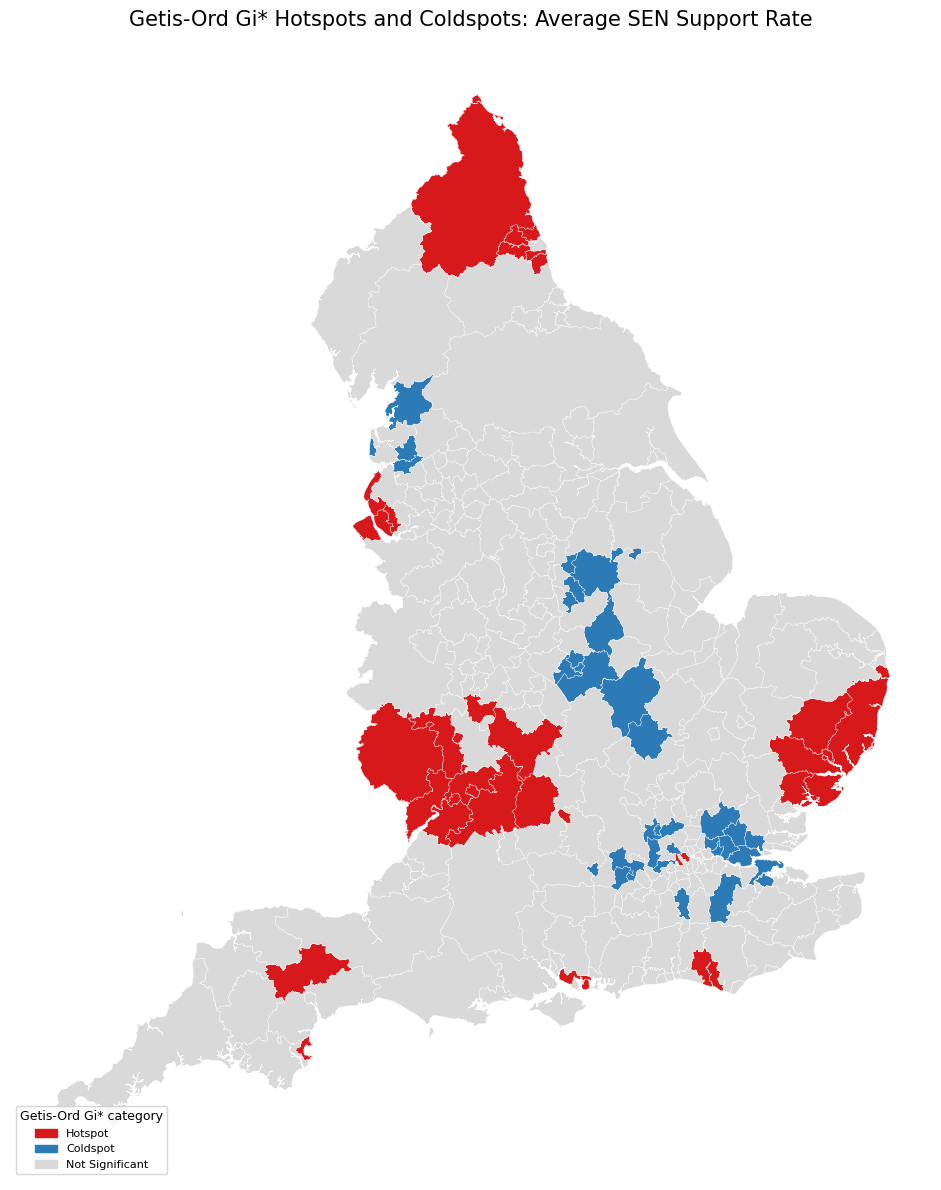

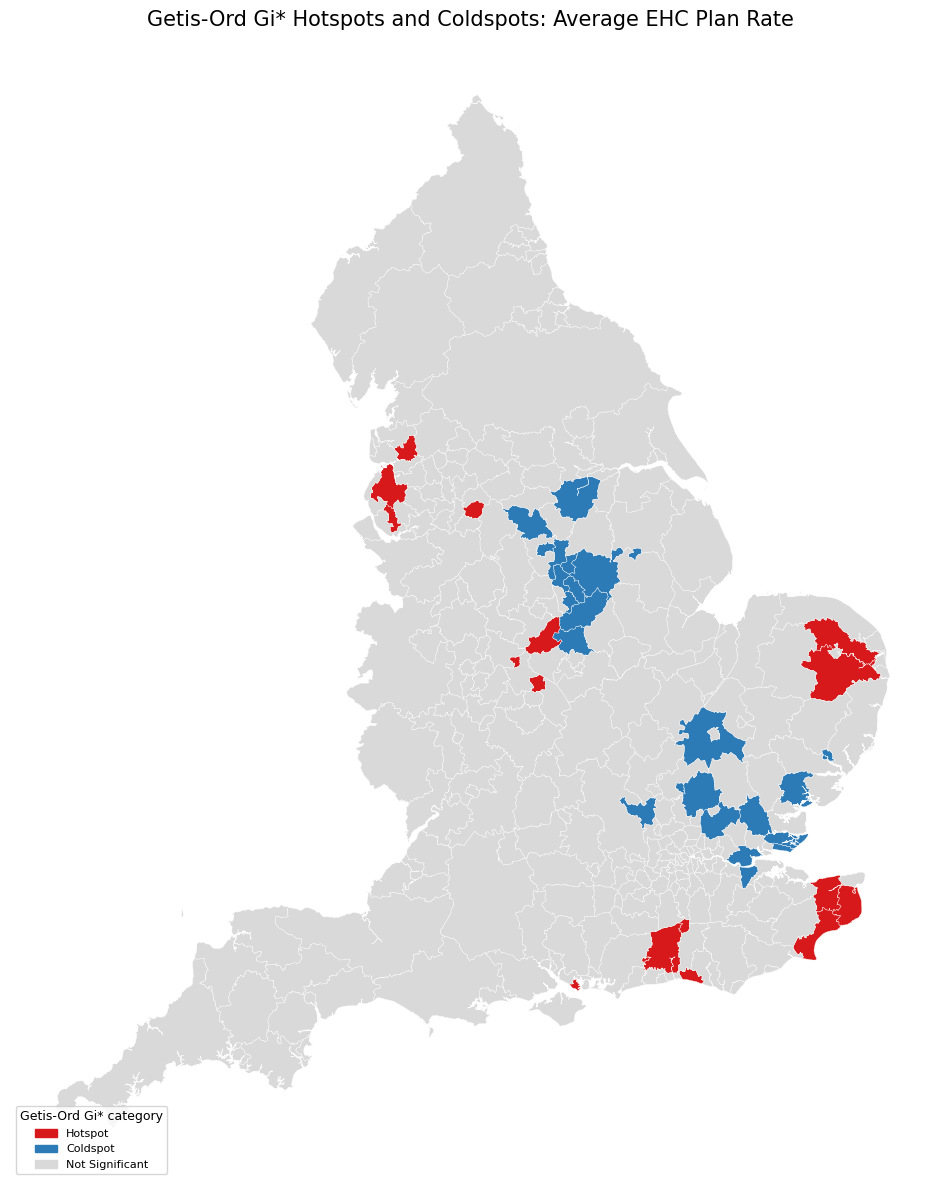

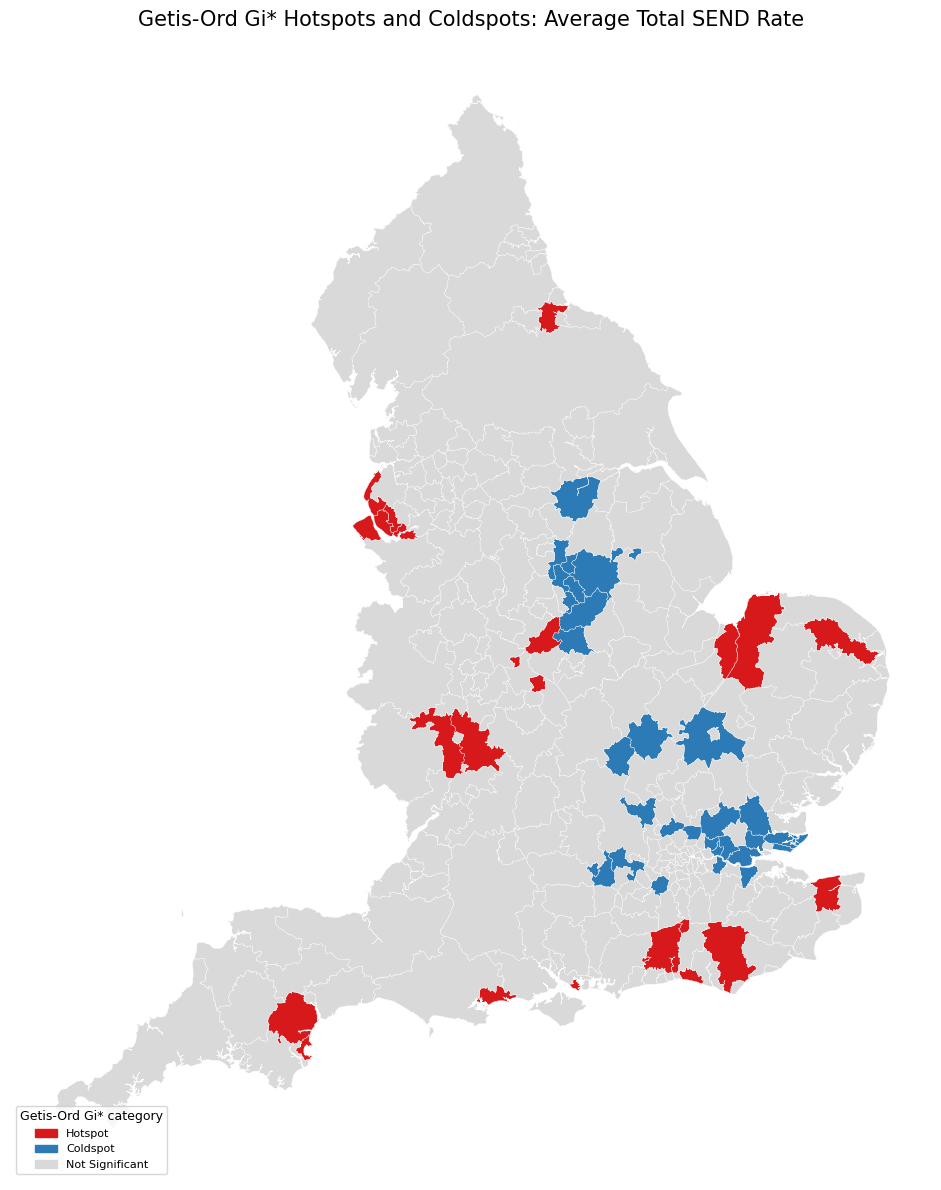

In [ ]:



#Produce one hotspot/coldspot map for each SEND outcome.


HOTSPOT_TITLES = {
    "Average SEN Rate": (
        "Getis-Ord Gi* Hotspots and Coldspots: "
        "Average SEN Support Rate"
    ),
    "Average EHC Rate": (
        "Getis-Ord Gi* Hotspots and Coldspots: "
        "Average EHC Plan Rate"
    ),
    "Average Total SEND Rate": (
        "Getis-Ord Gi* Hotspots and Coldspots: "
        "Average Total SEND Rate"
    )
}

HOTSPOT_FILENAMES = {
    "Average SEN Rate": "LA_SEN_Getis_Ord_Map.png",
    "Average EHC Rate": "LA_EHC_Getis_Ord_Map.png",
    "Average Total SEND Rate":
        "LA_Total_SEND_Getis_Ord_Map.png"
}

for outcome in SPATIAL_OUTCOMES:

    output_path = os.path.join(
        SPATIAL_OUTPUT_FOLDER,
        HOTSPOT_FILENAMES[outcome]
    )

    create_hotspot_map(
        hotspot_geodataframe=(
            getis_ord_gdfs[outcome]
        ),
        title=HOTSPOT_TITLES[outcome],
        output_path=output_path
    )

## SECTION 2.40 -COMPARE LISA AND GETIS-ORD CLASSIFICATIONS


In [ ]:



#Determine whether the two local spatial methods identify similar
#areas of high and low SEND concentration.

#High-High LISA clusters can be compared with Gi* hotspots.
#Low-Low LISA clusters can be compared with Gi* coldspots.


spatial_method_comparisons = {}

for outcome in SPATIAL_OUTCOMES:

    lisa_data = local_moran_gdfs[outcome][
        [
            "LAD24CD",
            "LA Authority",
            "LISA Cluster"
        ]
    ].copy()

    gi_data = getis_ord_gdfs[outcome][
        [
            "LAD24CD",
            "Gi Category"
        ]
    ].copy()

    comparison = lisa_data.merge(
        gi_data,
        on="LAD24CD",
        how="left"
    )

    comparison["Methods Agree"] = np.select(
        [
            (
                comparison["LISA Cluster"]
                == "High-High"
            )
            & (
                comparison["Gi Category"]
                == "Hotspot"
            ),
            (
                comparison["LISA Cluster"]
                == "Low-Low"
            )
            & (
                comparison["Gi Category"]
                == "Coldspot"
            )
        ],
        [
            "High-value agreement",
            "Low-value agreement"
        ],
        default="No direct agreement"
    )

    spatial_method_comparisons[outcome] = (
        comparison
    )

    print(f"\nMethod agreement: {outcome}")

    display(
        comparison[
            "Methods Agree"
        ]
        .value_counts()
        .rename_axis("Agreement Type")
        .reset_index(name="Number of LAs")
    )


Method agreement: Average SEN Rate


,Agreement Type,Number of LAs
0,No direct agreement,236
1,High-value agreement,30
2,Low-value agreement,28



Method agreement: Average EHC Rate


,Agreement Type,Number of LAs
0,No direct agreement,274
1,Low-value agreement,15
2,High-value agreement,5



Method agreement: Average Total SEND Rate


,Agreement Type,Number of LAs
0,No direct agreement,257
1,Low-value agreement,22
2,High-value agreement,15


## SECTION 2.41 -CONSOLIDATE ALL SPATIAL RESULTS


In [ ]:



#Add Local Moran and Getis-Ord results for all three SEND
#outcomes to one geographic dataset.



spatial_results_gdf = (
    la_gdf_bng.copy()
)

OUTCOME_PREFIXES = {
    "Average SEN Rate": "SEN",
    "Average EHC Rate": "EHC",
    "Average Total SEND Rate": "TOTAL_SEND"
}

for outcome, prefix in (
    OUTCOME_PREFIXES.items()
):

    lisa_gdf = local_moran_gdfs[outcome]
    gi_gdf = getis_ord_gdfs[outcome]

    spatial_results_gdf[
        f"{prefix}_Local_Moran_I"
    ] = lisa_gdf["Local Moran I"].values

    spatial_results_gdf[
        f"{prefix}_LISA_p"
    ] = lisa_gdf[
        "Local Moran p-value"
    ].values

    spatial_results_gdf[
        f"{prefix}_LISA_Cluster"
    ] = lisa_gdf["LISA Cluster"].values

    spatial_results_gdf[
        f"{prefix}_Gi_Z"
    ] = gi_gdf["Gi Z-score"].values

    spatial_results_gdf[
        f"{prefix}_Gi_p"
    ] = gi_gdf["Gi p-value"].values

    spatial_results_gdf[
        f"{prefix}_Gi_Category"
    ] = gi_gdf["Gi Category"].values

print("Consolidated spatial-results dataset created.")

display(
    spatial_results_gdf[
        [
            "LA Authority",
            "SEN_LISA_Cluster",
            "EHC_LISA_Cluster",
            "TOTAL_SEND_LISA_Cluster",
            "SEN_Gi_Category",
            "EHC_Gi_Category",
            "TOTAL_SEND_Gi_Category"
        ]
    ].head()
)

Consolidated spatial-results dataset created.


,LA Authority,SEN_LISA_Cluster,EHC_LISA_Cluster,TOTAL_SEND_LISA_Cluster,SEN_Gi_Category,EHC_Gi_Category,TOTAL_SEND_Gi_Category
0,Adur,Not Significant,Not Significant,Not Significant,Not Significant,Not Significant,Not Significant
1,Amber Valley,Not Significant,Not Significant,Not Significant,Not Significant,Not Significant,Not Significant
2,Arun,Not Significant,Not Significant,Not Significant,Not Significant,Not Significant,Not Significant
3,Ashfield,Not Significant,Low-Low,Low-Low,Not Significant,Coldspot,Coldspot
4,Ashford,Not Significant,Not Significant,Not Significant,Not Significant,Not Significant,Not Significant


In [ ]:



#Add Local Moran and Getis-Ord results for all three SEND
#outcomes to one geographic dataset.


spatial_results_gdf = (
    la_gdf_bng.copy()
)

OUTCOME_PREFIXES = {
    "Average SEN Rate": "SEN",
    "Average EHC Rate": "EHC",
    "Average Total SEND Rate": "TOTAL_SEND"
}

for outcome, prefix in (
    OUTCOME_PREFIXES.items()
):

    lisa_gdf = local_moran_gdfs[outcome]
    gi_gdf = getis_ord_gdfs[outcome]

    spatial_results_gdf[
        f"{prefix}_Local_Moran_I"
    ] = lisa_gdf["Local Moran I"].values

    spatial_results_gdf[
        f"{prefix}_LISA_p"
    ] = lisa_gdf[
        "Local Moran p-value"
    ].values

    spatial_results_gdf[
        f"{prefix}_LISA_Cluster"
    ] = lisa_gdf["LISA Cluster"].values

    spatial_results_gdf[
        f"{prefix}_Gi_Z"
    ] = gi_gdf["Gi Z-score"].values

    spatial_results_gdf[
        f"{prefix}_Gi_p"
    ] = gi_gdf["Gi p-value"].values

    spatial_results_gdf[
        f"{prefix}_Gi_Category"
    ] = gi_gdf["Gi Category"].values

print("Consolidated spatial-results dataset created.")

display(
    spatial_results_gdf[
        [
            "LA Authority",
            "SEN_LISA_Cluster",
            "EHC_LISA_Cluster",
            "TOTAL_SEND_LISA_Cluster",
            "SEN_Gi_Category",
            "EHC_Gi_Category",
            "TOTAL_SEND_Gi_Category"
        ]
    ].head()
)

Consolidated spatial-results dataset created.


,LA Authority,SEN_LISA_Cluster,EHC_LISA_Cluster,TOTAL_SEND_LISA_Cluster,SEN_Gi_Category,EHC_Gi_Category,TOTAL_SEND_Gi_Category
0,Adur,Not Significant,Not Significant,Not Significant,Not Significant,Not Significant,Not Significant
1,Amber Valley,Not Significant,Not Significant,Not Significant,Not Significant,Not Significant,Not Significant
2,Arun,Not Significant,Not Significant,Not Significant,Not Significant,Not Significant,Not Significant
3,Ashfield,Not Significant,Low-Low,Low-Low,Not Significant,Coldspot,Coldspot
4,Ashford,Not Significant,Not Significant,Not Significant,Not Significant,Not Significant,Not Significant


In [ ]:



#Add Local Moran and Getis-Ord results for all three SEND
#outcomes to one geographic dataset.




spatial_results_gdf = (
    la_gdf_bng.copy()
)

OUTCOME_PREFIXES = {
    "Average SEN Rate": "SEN",
    "Average EHC Rate": "EHC",
    "Average Total SEND Rate": "TOTAL_SEND"
}

for outcome, prefix in (
    OUTCOME_PREFIXES.items()
):

    lisa_gdf = local_moran_gdfs[outcome]
    gi_gdf = getis_ord_gdfs[outcome]

    spatial_results_gdf[
        f"{prefix}_Local_Moran_I"
    ] = lisa_gdf["Local Moran I"].values

    spatial_results_gdf[
        f"{prefix}_LISA_p"
    ] = lisa_gdf[
        "Local Moran p-value"
    ].values

    spatial_results_gdf[
        f"{prefix}_LISA_Cluster"
    ] = lisa_gdf["LISA Cluster"].values

    spatial_results_gdf[
        f"{prefix}_Gi_Z"
    ] = gi_gdf["Gi Z-score"].values

    spatial_results_gdf[
        f"{prefix}_Gi_p"
    ] = gi_gdf["Gi p-value"].values

    spatial_results_gdf[
        f"{prefix}_Gi_Category"
    ] = gi_gdf["Gi Category"].values

print("Consolidated spatial-results dataset created.")

display(
    spatial_results_gdf[
        [
            "LA Authority",
            "SEN_LISA_Cluster",
            "EHC_LISA_Cluster",
            "TOTAL_SEND_LISA_Cluster",
            "SEN_Gi_Category",
            "EHC_Gi_Category",
            "TOTAL_SEND_Gi_Category"
        ]
    ].head()
)

Consolidated spatial-results dataset created.


,LA Authority,SEN_LISA_Cluster,EHC_LISA_Cluster,TOTAL_SEND_LISA_Cluster,SEN_Gi_Category,EHC_Gi_Category,TOTAL_SEND_Gi_Category
0,Adur,Not Significant,Not Significant,Not Significant,Not Significant,Not Significant,Not Significant
1,Amber Valley,Not Significant,Not Significant,Not Significant,Not Significant,Not Significant,Not Significant
2,Arun,Not Significant,Not Significant,Not Significant,Not Significant,Not Significant,Not Significant
3,Ashfield,Not Significant,Low-Low,Low-Low,Not Significant,Coldspot,Coldspot
4,Ashford,Not Significant,Not Significant,Not Significant,Not Significant,Not Significant,Not Significant


## SECTION 2.42 -SAVE SPATIAL RESULT TABLES TO EXCEL


In [ ]:




SPATIAL_TABLE_PATH = os.path.join(
    SPATIAL_OUTPUT_FOLDER,
    "Spatial_Analysis_Results.xlsx"
)

with pd.ExcelWriter(
    SPATIAL_TABLE_PATH,
    engine="openpyxl"
) as writer:

    global_moran_table.to_excel(
        writer,
        sheet_name="Global Morans I",
        index=False
    )

    neighbour_summary.to_excel(
        writer,
        sheet_name="Neighbour Counts",
        index=False
    )

    for outcome, prefix in (
        OUTCOME_PREFIXES.items()
    ):

        significant_lisa_tables[
            outcome
        ].drop(
            columns="geometry",
            errors="ignore"
        ).to_excel(
            writer,
            sheet_name=f"{prefix} LISA Results"[:31],
            index=False
        )

        spatial_outlier_tables[
            outcome
        ].drop(
            columns="geometry",
            errors="ignore"
        ).to_excel(
            writer,
            sheet_name=f"{prefix} Spatial Outliers"[:31],
            index=False
        )

        hotspot_table = getis_ord_gdfs[
            outcome
        ][
            [
                "LA Authority",
                "LAD24CD",
                outcome,
                "Gi Z-score",
                "Gi p-value",
                "Gi Category"
            ]
        ].copy()

        hotspot_table.to_excel(
            writer,
            sheet_name=f"{prefix} Gi Results"[:31],
            index=False
        )

print("Spatial result tables saved successfully:")
print(SPATIAL_TABLE_PATH)

Spatial result tables saved successfully:
/content/drive/MyDrive/MSC Dissertation/Final Main 3/Analysis Outputs/Spatial Analysis/Spatial_Analysis_Results.xlsx


## SECTION 2.43 -SAVE THE GEOGRAPHIC SPATIAL RESULTS


In [ ]:



#Save all Local Authority boundaries and spatial classifications
#in a GeoPackage.
#
#A GeoPackage retains geographic geometry and can be opened in:
#-GeoPandas;
#-QGIS;
#-ArcGIS;
#-other GIS software.


SPATIAL_GEOPACKAGE_PATH = os.path.join(
    SPATIAL_OUTPUT_FOLDER,
    "LA_Spatial_Analysis_Results.gpkg"
)

spatial_results_gdf.to_file(
    SPATIAL_GEOPACKAGE_PATH,
    layer="LA_spatial_results",
    driver="GPKG"
)

print("Geographic spatial results saved successfully:")
print(SPATIAL_GEOPACKAGE_PATH)

Geographic spatial results saved successfully:
/content/drive/MyDrive/MSC Dissertation/Final Main 3/Analysis Outputs/Spatial Analysis/LA_Spatial_Analysis_Results.gpkg


## SECTION 2.44 -SAVE A NON-SPATIAL EXCEL COPY


In [ ]:



#Save the consolidated result fields without geometry for easy
#viewing and use in tables.


SPATIAL_EXCEL_COPY_PATH = os.path.join(
    SPATIAL_OUTPUT_FOLDER,
    "LA_Spatial_Results_Non_Geographic.xlsx"
)

spatial_results_non_geographic = (
    pd.DataFrame(
        spatial_results_gdf.drop(
            columns="geometry"
        )
    )
)

spatial_results_non_geographic.to_excel(
    SPATIAL_EXCEL_COPY_PATH,
    index=False
)

print("Non-geographic spatial results saved:")
print(SPATIAL_EXCEL_COPY_PATH)

Non-geographic spatial results saved:
/content/drive/MyDrive/MSC Dissertation/Final Main 3/Analysis Outputs/Spatial Analysis/LA_Spatial_Results_Non_Geographic.xlsx


## SECTION 2.45 -PRINT THE SPATIAL-ANALYSIS SUMMARY


In [ ]:



#Present the most important Global and Local spatial findings in
#one concise output.


print("=" * 75)
print("SECTION 3: SPATIAL-ANALYSIS SUMMARY")
print("=" * 75)

print(
    "\nSpatial weights method:",
    spatial_weights_method
)

print(
    "Number of Local Authorities:",
    spatial_weights.n
)

print(
    "Average neighbours per authority:",
    round(spatial_weights.mean_neighbors, 2)
)

for outcome in SPATIAL_OUTCOMES:

    global_row = global_moran_table[
        global_moran_table["Outcome"]
        == outcome
    ].iloc[0]

    lisa_counts = (
        local_moran_gdfs[outcome][
            "LISA Cluster"
        ]
        .value_counts()
    )

    gi_counts = (
        getis_ord_gdfs[outcome][
            "Gi Category"
        ]
        .value_counts()
    )

    print("\n" + "-" * 75)
    print(outcome)

    print(
        "Global Moran's I:",
        round(global_row["Moran's I"], 4)
    )

    print(
        "Permutation p-value:",
        round(
            global_row[
                "Permutation p-value"
            ],
            4
        )
    )

    print(
        "Interpretation:",
        global_row["Interpretation"]
    )

    print(
        "High-High clusters:",
        int(
            lisa_counts.get(
                "High-High",
                0
            )
        )
    )

    print(
        "Low-Low clusters:",
        int(
            lisa_counts.get(
                "Low-Low",
                0
            )
        )
    )

    print(
        "High-Low spatial outliers:",
        int(
            lisa_counts.get(
                "High-Low",
                0
            )
        )
    )

    print(
        "Low-High spatial outliers:",
        int(
            lisa_counts.get(
                "Low-High",
                0
            )
        )
    )

    print(
        "Gi* hotspots:",
        int(
            gi_counts.get(
                "Hotspot",
                0
            )
        )
    )

    print(
        "Gi* coldspots:",
        int(
            gi_counts.get(
                "Coldspot",
                0
            )
        )
    )

SECTION 3: SPATIAL-ANALYSIS SUMMARY

Spatial weights method: Four-nearest neighbours
Number of Local Authorities: 294
Average neighbours per authority: 4.0

---------------------------------------------------------------------------
Average SEN Rate
Global Moran's I: 0.2576
Permutation p-value: 0.001
Interpretation: Statistically significant positive spatial clustering
High-High clusters: 31
Low-Low clusters: 33
High-Low spatial outliers: 8
Low-High spatial outliers: 4
Gi* hotspots: 35
Gi* coldspots: 35

---------------------------------------------------------------------------
Average EHC Rate
Global Moran's I: 0.1065
Permutation p-value: 0.004
Interpretation: Statistically significant positive spatial clustering
High-High clusters: 5
Low-Low clusters: 18
High-Low spatial outliers: 7
Low-High spatial outliers: 9
Gi* hotspots: 16
Gi* coldspots: 24

---------------------------------------------------------------------------
Average Total SEND Rate
Global Moran's I: 0.2097
Permutation p

## SECTION 2.46 -SPATIAL-WEIGHTS SENSITIVITY CHECK


In [ ]:



#Compare Global Moran's I under:
#1.Queen boundary contiguity
#2.Four-nearest neighbours
#
#Similar conclusions under both methods increase confidence that
#the spatial result is not caused solely by one weights choice.


knn_four_weights = KNN.from_dataframe(
    la_gdf_bng,
    k=4,
    ids=la_gdf_bng["LAD24CD"].tolist(),
    use_index=False
)

knn_four_weights.transform = "R"

queen_weights.transform = "R"

sensitivity_results = []

for outcome in SPATIAL_OUTCOMES:

    values = (
        la_gdf_bng[outcome]
        .astype(float)
        .to_numpy()
    )

    queen_moran = Moran(
        values,
        queen_weights,
        permutations=999
    )

    knn_moran = Moran(
        values,
        knn_four_weights,
        permutations=999
    )

    sensitivity_results.extend(
        [
            {
                "Outcome": outcome,
                "Weights Method":
                    "Queen contiguity",
                "Moran's I":
                    queen_moran.I,
                "Permutation p-value":
                    queen_moran.p_sim
            },
            {
                "Outcome": outcome,
                "Weights Method":
                    "Four-nearest neighbours",
                "Moran's I":
                    knn_moran.I,
                "Permutation p-value":
                    knn_moran.p_sim
            }
        ]
    )

spatial_weights_sensitivity = pd.DataFrame(
    sensitivity_results
)

display(
    spatial_weights_sensitivity.round(4)
)

,Outcome,Weights Method,Moran's I,Permutation p-value
0,Average SEN Rate,Queen contiguity,0.1950,0.001
1,Average SEN Rate,Four-nearest neighbours,0.2576,0.001
2,Average EHC Rate,Queen contiguity,0.0728,0.032
3,Average EHC Rate,Four-nearest neighbours,0.1065,0.006
4,Average Total SEND Rate,Queen contiguity,0.1444,0.001
5,Average Total SEND Rate,Four-nearest neighbours,0.2097,0.001
